In [74]:
import configparser
import pylab as pl
import os
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [75]:
#Define a function to load both R1 and R2 files
def get_directory_path(i):
    # Replace 'base_directory' with the base directory path where your CSV files are stored
    base_directory = 'C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Sperimentazione UIT/Software'
    
    # Create a subdirectory name based on the 'i' index
    subdirectory_name = f'R{i}'
    
    # Combine the base directory and subdirectory to get the full path
    full_directory_path = os.path.join(base_directory, subdirectory_name)
    # Replace backslashes with forward slashes
    full_directory_path = full_directory_path.replace('\\', '/')
    
    return full_directory_path
for i in range(1,2+1):
 print(get_directory_path(i))

C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Sperimentazione UIT/Software/R1
C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Sperimentazione UIT/Software/R2


In [84]:
# Specify the start and end dates for the range you want to read
# The very start was 19.10.2023
start_date = datetime(2024, 4, 20)  # Start date in the format: YYYY, MM, DD
end_date = datetime(2024, 5, 6)  # End date in the format: YYYY, MM, DD

# Number of dataframes you want to create
num_dataframes = 2

# Create a dictionary to store the dataframes
dataframes_dict = {}

# Loop to create dataframes
for i in range(1, num_dataframes + 1):
    dataframes = []
    # Loop through the dates in the specified range and read the corresponding .csv files
    current_date = start_date
    while current_date <= end_date:
        file_name = f"{current_date.strftime('%Y-%m-%d')}_R{i}.csv"  # Updated date format
        directory_path = get_directory_path(i)
        file_path = os.path.join(directory_path, file_name)  # Join directory path with file name
        file_path = file_path.replace('\\', '/')

        try:
            # Read the .csv file and append the dataframe to the list
            df = pd.read_csv(file_path,encoding='ISO-8859-1',delimiter = ';', 
                       parse_dates=['Timestamp'], dayfirst=True)
            dataframes.append(df)
            #print(f"Successfully read {file_name}")
        except FileNotFoundError:
            print(f"File {file_name} not found at path {file_path}.")

        # Move to the next day
        current_date += timedelta(days=1)

    # Now, dataframes list contains all the dataframes from the .csv files for the specified date range
    # You can access them using dataframes[0], dataframes[1], ..., dataframes[N-1]

    # Concatenate all the dataframes into one
    combined_dataframe = pd.concat(dataframes, ignore_index=True)
    
    # Assign the dataframe to a key in the dictionary
    dataframes_dict[f'R{i}'] = combined_dataframe

    # Access the dataframes using the dictionary
    #print(dataframes_dict[f'R{i}'])

R1 = dataframes_dict['R1']
R2 = dataframes_dict['R2']

#-------------------------------------------------------------------------------------------------------------
# Read analyzer data

dataframes_a = []
# Loop through the dates in the specified range and read the corresponding .csv files
current_date = start_date
while current_date <= end_date:
    file_name = f"{current_date.strftime('%Y-%m-%d')}_Analyse.csv"  # Updated date format
    directory_path = 'C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Sperimentazione UIT/Software/Analyse'
    file_path = os.path.join(directory_path, file_name)  # Join directory path with file name
    file_path = file_path.replace('\\', '/')

    try:
        # Read the .csv file and append the dataframe to the list
        df = pd.read_csv(file_path,encoding='ISO-8859-1',delimiter = ';', 
                   parse_dates=['Timestamp'], dayfirst=True)
        dataframes_a.append(df)
        #print(f"Successfully read {file_name}")
    except FileNotFoundError:
        print(f"File {file_name} not found at path {file_path}.")

    # Move to the next day
    current_date += timedelta(days=1)

# Now, dataframes list contains all the dataframes from the .csv files for the specified date range
# You can access them using dataframes[0], dataframes[1], ..., dataframes[N-1]

# Concatenate all the dataframes into one
combined_dataframe_a = pd.concat(dataframes_a, ignore_index=True)

# Assign the dataframe to a key in the dictionary
dataframes_dict[f'Analyse'] = combined_dataframe_a


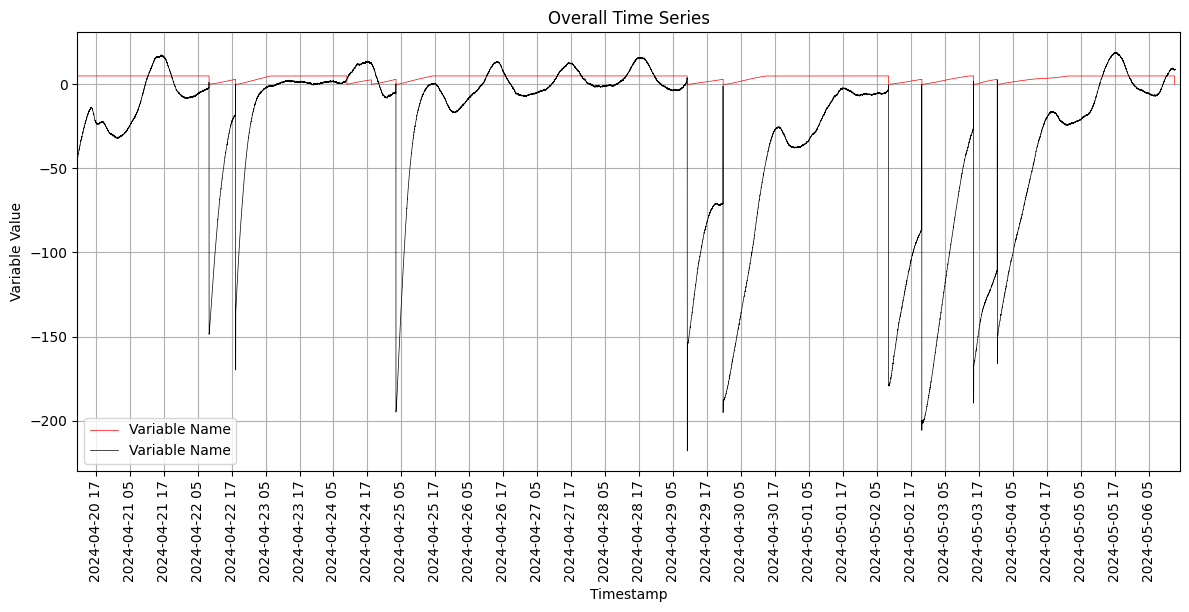

In [87]:
import matplotlib.dates as mdates
# Plot the overall time series
plt.figure(figsize=(12, 6))
plt.plot(R1['Timestamp'], R1['1X11F1 [L]'], color='r', label='Variable Name',linewidth=0.5)
plt.plot(dataframes_dict[f'Analyse']['Timestamp'], dataframes_dict[f'Analyse']['12P2 [mbar]'], color='black', label='Variable Name',linewidth=0.5)
plt.xlabel('Timestamp')
plt.ylabel('Variable Value')
plt.title('Overall Time Series')
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
ax = plt.gca()
#ax.set_xlim([xmin, xmax])
#ax.set_ylim([0, 10])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

# Set x-axis limits with timestamps (from 10:30 AM to 12:30 PM)
start_time = datetime(2024, 4, 20, 10, 30)
end_time = datetime(2024, 5, 6, 16, 0)
plt.xlim(mdates.date2num(start_time), mdates.date2num(end_time))
ax = plt.gca()
#ax.set_ylim([42, 42.4])
#ax.set_xlim([15000,15015])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d %H') #('%Y-%m-%d %H:%m')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.HourLocator(interval=12))

plt.grid()

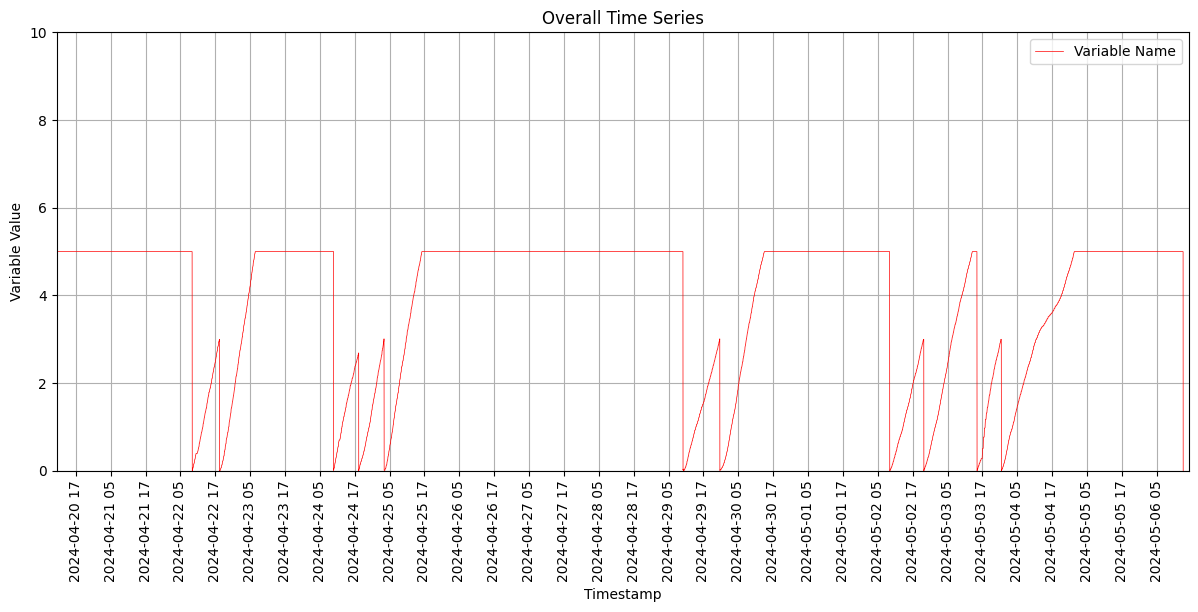

In [89]:
import matplotlib.dates as mdates
# Plot the overall time series
plt.figure(figsize=(12, 6))
plt.plot(R1['Timestamp'], R1['1X11F1 [L]'], color='r', label='Variable Name',linewidth=0.5)
plt.xlabel('Timestamp')
plt.ylabel('Variable Value')
plt.title('Overall Time Series')
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
ax = plt.gca()
#ax.set_xlim([xmin, xmax])
ax.set_ylim([0, 10])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

# Set x-axis limits with timestamps (from 10:30 AM to 12:30 PM)
start_time = datetime(2024, 4, 20, 10, 30)
end_time = datetime(2024, 5, 6, 16, 0)
plt.xlim(mdates.date2num(start_time), mdates.date2num(end_time))
ax = plt.gca()
#ax.set_ylim([42, 42.4])
#ax.set_xlim([15000,15015])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d %H') #('%Y-%m-%d %H:%m')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.HourLocator(interval=12))

plt.grid()

In [41]:
mean_R2 = R2['2F1.1 [L/h]'].mean()
stdev_R2 = R2['2F1.1 [L/h]'].std()
mean_R1 = R1['1F1.1 [L/h]'].mean()
stdev_R1 = R1['1F1.1 [L/h]'].std()

In [ ]:
#To check outlier (and neighborhood) values and position before replacement
#index = R2['2F1.1 [L/h]'].index
#plt.plot(R2['2F1.1 [L/h]'].index, R2['2F1.1 [L/h]'], color='r', label='Variable Name',linewidth=0.5)
#ax = plt.gca()
#ax.set_xlim([7500, 8000])
#ax.set_ylim([0, 20])

In [54]:
#OUTLIER DETECTION AND REPLACEMENT
#Z-score method: average and st.dev. calculated with respect to the overall time series 
#or with respect to the sliding window?
import numpy as np

for i in range(1,3):
 for name, df in dataframes_dict.items():
    rate = f'{i}F1.1 [L/h]'
    pH = f'{i}Q1 [pH]'
    T = f'{i}T1 [°C]'
    if rate in df.columns:
        
        df['Z-score_rate'] = np.abs((df[rate] - df[rate].mean()) / df[rate].std())
        df['Z-score_pH'] = np.abs((df[pH] - df[pH].mean()) / df[pH].std())
        # Replace outliers with the mean of the closest previous and next neighbors
        threshold = 6  # Define your threshold for Z-score
        # Find indices of outliers
        outlier_indices_rate = np.where(df['Z-score_rate'] > threshold)[0]
        outlier_indices_pH = np.where(df['Z-score_pH'] > threshold)[0]
        #combined_dataframe['2F1.1 [L/h]_out'] = np.where(combined_dataframe['Z-score'] > threshold, combined_dataframe['2F1.1 [L/h]'].rolling(window=50, min_periods=1, center=True).mean(), combined_dataframe['2F1.1 [L/h]'])

        # Drop the 'Z-score' column if no longer needed
        #combined_dataframe = combined_dataframe.drop('Z-score', axis=1)

        # Create a new column 'interpolated_data' with the original data
        df[f'{i}F1.1 [L/h]_out'] = df[rate]
        df[f'{i}Q1 [pH]_out'] = df[pH]
        df[f'{i}T1 [°C]_out'] =  df[T]

        # Replace outliers with linear interpolation
        interpolated_values_list_rate = []
        interpolated_values_list_pH = []
        interpolated_values_list_T = []
        #for idx in outlier_indices:
        #    if 0 < idx < len(combined_dataframe) - 1 and idx not in outlier_indices:
        #        prev_valid_idx = combined_dataframe['2F1.1 [L/h]_out'].index[combined_dataframe['2F1.1 [L/h]_out'].iloc[:idx].notnull()].max()
        #        next_valid_idx = combined_dataframe['2F1.1 [L/h]_out'].index[combined_dataframe['2F1.1 [L/h]_out'].iloc[idx:].notnull()].min()
        #        if prev_valid_idx is not pd.NA and next_valid_idx is not pd.NA:
        #            prev_value = combined_dataframe.at[prev_valid_idx, '2F1.1 [L/h]_out']
        #            next_value = combined_dataframe.at[next_valid_idx, '2F1.1 [L/h]_out']
        #            interpolated_value = prev_value + (next_value - prev_value) / (next_valid_idx - prev_valid_idx).days * (idx - prev_valid_idx).days
        #            interpolated_values_list.append = interpolated_value
        #            combined_dataframe.at[idx, '2F1.1 [L/h]_out'] = interpolated_value

        for idx in outlier_indices_rate:
            prev_idx = idx-1
            while prev_idx in outlier_indices_rate:
                prev_idx = prev_idx-1
            next_idx = idx+1
            while next_idx in outlier_indices_rate:
                next_idx = next_idx+1
            interpolated_value = df.at[prev_idx, f'{i}F1.1 [L/h]_out'] + ((idx - prev_idx) * (df.at[next_idx, f'{i}F1.1 [L/h]_out'] - df.at[prev_idx, f'{i}F1.1 [L/h]_out'])) / (next_idx - prev_idx)
            interpolated_values_list_rate.append(prev_idx)
            df.at[idx, f'{i}F1.1 [L/h]_out'] = interpolated_value
            
        for idx in outlier_indices_pH:
            prev_idx = idx-1
            while prev_idx in outlier_indices_pH:
                prev_idx = prev_idx-1
            next_idx = idx+1
            while next_idx in outlier_indices_pH:
                next_idx = next_idx+1
            interpolated_value = df.at[prev_idx, f'{i}Q1 [pH]_out'] + ((idx - prev_idx) * (df.at[next_idx, f'{i}Q1 [pH]_out'] - df.at[prev_idx, f'{i}Q1 [pH]_out'])) / (next_idx - prev_idx)
            interpolated_values_list_pH.append(prev_idx)
            df.at[idx, f'{i}Q1 [pH]_out'] = interpolated_value
            
        for idx in outlier_indices_pH:
            prev_idx = idx-1
            while prev_idx in outlier_indices_pH:
                prev_idx = prev_idx-1
            next_idx = idx+1
            while next_idx in outlier_indices_pH:
                next_idx = next_idx+1
            interpolated_value = df.at[prev_idx, f'{i}T1 [°C]_out'] + ((idx - prev_idx) * (df.at[next_idx, f'{i}T1 [°C]_out'] - df.at[prev_idx, f'{i}T1 [°C]_out'])) / (next_idx - prev_idx)
            interpolated_values_list_pH.append(prev_idx)
            df.at[idx, f'{i}T1 [°C]_out'] = interpolated_value

        # Updated time series data with outliers replaced by interpolated values
        updated_time_series_rate = df[f'{i}F1.1 [L/h]_out']
        updated_time_series_pH = df[f'{i}Q1 [pH]_out']
        updated_time_series_T = df[f'{i}T1 [°C]_out']

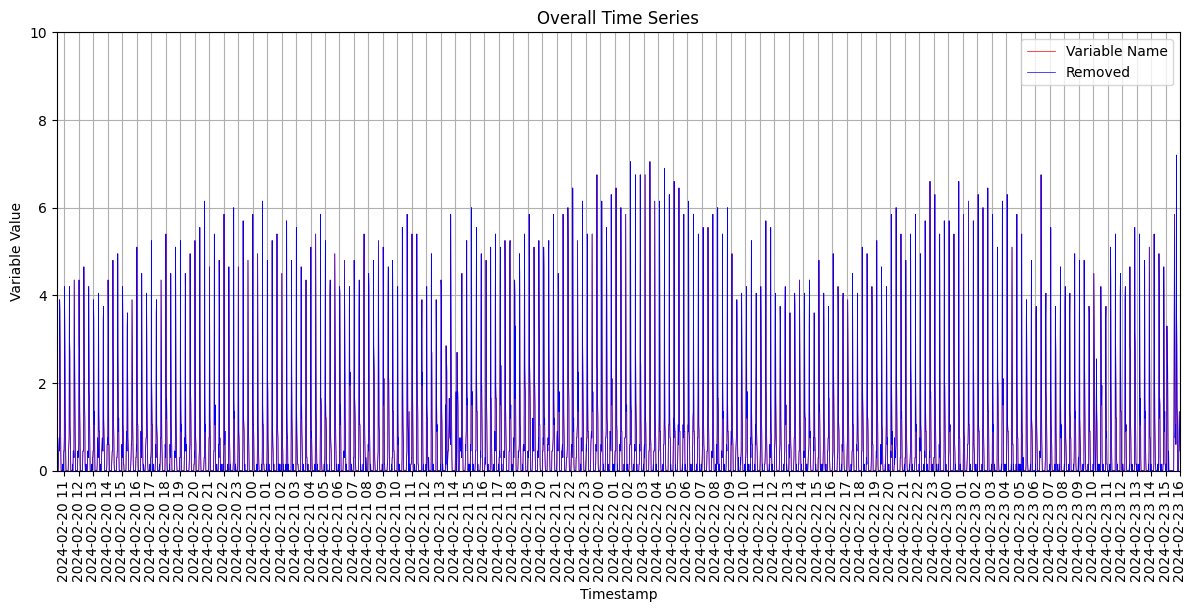

In [81]:
#GAS RATE PLOTS
import matplotlib.dates as mdates
# Plot the overall time series
plt.figure(figsize=(12, 6))
#plt.plot(R1['Timestamp'], R1['1F1.1 [L/h]'], color='b', label='Variable Name',linewidth=0.5)  # Replace 'variable_name' with your actual variable name
plt.plot(R2['Timestamp'], R2['2F1.1 [L/h]'], color='r', label='Variable Name',linewidth=0.5)
plt.plot(R2['Timestamp'], R2['2F1.1 [L/h]_out'], color='b', label='Removed',linewidth=0.5)
plt.xlabel('Timestamp')
plt.ylabel('Variable Value')
plt.title('Overall Time Series')
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
ax = plt.gca()
#ax.set_xlim([xmin, xmax])
ax.set_ylim([0, 10])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

# Set x-axis limits with timestamps (from 10:30 AM to 12:30 PM)
start_time = datetime(2024, 2, 20, 10, 30)
end_time = datetime(2024, 2, 23, 16, 0)
plt.xlim(mdates.date2num(start_time), mdates.date2num(end_time))
ax = plt.gca()
#ax.set_ylim([42, 42.4])
#ax.set_xlim([15000,15015])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d %H') #('%Y-%m-%d %H:%m')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))

plt.grid()
plt.show()

In [55]:
#MOVING AVERAGE
# Calculate the moving average with a window
for i in range(1,3):
 for name, df in dataframes_dict.items():
    rate_out = f'{i}F1.1 [L/h]_out'
    if rate_out in df.columns:
        window_size = 60 #Hourly moving average
        df['rate_moving_average'] = df[rate_out].rolling(window=window_size).mean()

In [56]:
#Compute quantities of interest
#CH4 flowrate
# Calculate the moving average with a window
for i in range(1,3):
 for name, df in dataframes_dict.items():
    ch4_percentage = f'{i}X11Q3 [V% CH4]'
    co2_percentage = f'{i}X11Q2 [V% CO2]' 
    if ch4_percentage and co2_percentage in df.columns:
        df['ch4_rate_moving_average'] = df['rate_moving_average']*df[ch4_percentage]/100
        df['co2_rate_moving_average'] = df['rate_moving_average']*df[co2_percentage]/100
        df['gas_ratio'] = np.where(df[co2_percentage] == 0, 0, df[ch4_percentage]/df[co2_percentage])

In [57]:
# Two ways to do this: 
#result_old = df.groupby('interval')[rate_out].mean()
#result_df = df.groupby(pd.Grouper(key='Timestamp', freq='60Min')).agg({rate_out: custom_agg})

# Group by hour and calculate the average using a custom aggregation function
def custom_agg(series):
    return series.mean()

start_time = f'{start_date} 00:00:00'
start_time = pd.Timestamp(start_time)
#GROUPBY
groupby = []
groupby_Qch4 = []
groupby_ratio = []
groupby_pH = []
groupby_T = []
for i in range(1,3):
 for name, df in dataframes_dict.items():
    rate_out = f'{i}F1.1 [L/h]_out'
    ch4_percentage = f'{i}X11Q3 [V% CH4]'
    pH_out = f'{i}Q1 [pH]_out'
    T_out = f'{i}T1 [°C]_out'
    if rate_out and ch4_percentage and pH_out in df.columns:
        # Define the size of each interval
        interval_size = 60

        # Calculate the mean for each interval using groupby and custom binning
        df['interval'] = (df.index // interval_size) * interval_size
        result_old = df.groupby('interval')[rate_out].mean()
        result_df = df.groupby(pd.Grouper(key='Timestamp', freq='60Min')).agg({rate_out: custom_agg})
        result = result_df.reset_index()
        # OLD METHOD TO GROUPBY ------------------
        #result_old = result_old.reset_index()
        #timestamps = pd.date_range(start=start_time, periods=len(result), freq='H')  # Add timestamp column
        #timestamps = timestamps.strftime('%d.%m.%Y %H:%M:%S')
        # Insert the new column at a specific position (e.g., before 'Column2'). Alternative #result['Timestamp'] = timestamps
        #result.insert(loc=1, column='Timestamps', value=timestamps)
        # ---------------------------------------
        
        df['ch4_rate'] = df[rate_out]*df[ch4_percentage]/100
        result_Qch4 = df.groupby(pd.Grouper(key='Timestamp', freq='60Min')).agg({'ch4_rate': custom_agg})
        result_ratio = df.groupby(pd.Grouper(key='Timestamp', freq='60Min')).agg({'gas_ratio': custom_agg})
        result_pH = df.groupby(pd.Grouper(key='Timestamp', freq='60Min')).agg({pH_out: custom_agg})
        result_T = df.groupby(pd.Grouper(key='Timestamp', freq='60Min')).agg({T_out: custom_agg})
        # Reset index to transform DataFrame to regular column DataFrame
        result_Qch4 = result_Qch4.reset_index()
        result_ratio = result_ratio.reset_index()
        result_pH = result_pH.reset_index()
        result_T = result_T.reset_index()
        groupby.append(result)
        groupby_Qch4.append(result_Qch4)
        groupby_ratio.append(result_ratio)
        groupby_pH.append(result_pH)
        groupby_T.append(result_T)
        
        #Rename gas and pH column
        groupby[i-1].rename(columns={rate_out: 'gas_rate'}, inplace=True)
        groupby_pH[i-1].rename(columns={pH_out: 'pHs'}, inplace=True)
        groupby_T[i-1].rename(columns={T_out: 'T'}, inplace=True)

In [58]:
# Aggregate tomato for combi
# Group by hour and calculate the average using a custom aggregation function
def custom_agg(series):
    return series.sum()

#GROUPBY
groupby_tomato = []
for i in range(1,3):
 for name, df in dataframes_dict.items():
    tomato = f'{i}P4'
    if tomato in df.columns:
        # Define the size of each interval
        interval_size = 150

        # Calculate the mean for each interval using groupby and custom binning
        df['interval'] = (df.index // interval_size) * interval_size
        result_old = df.groupby('interval')[tomato].mean()
        result_df = df.groupby(pd.Grouper(key='Timestamp', freq='150Min')).agg({tomato: custom_agg})
        result = result_df.reset_index()
        # OLD METHOD TO GROUPBY ------------------
        #result_old = result_old.reset_index()
        #timestamps = pd.date_range(start=start_time, periods=len(result), freq='H')  # Add timestamp column
        #timestamps = timestamps.strftime('%d.%m.%Y %H:%M:%S')
        # Insert the new column at a specific position (e.g., before 'Column2'). Alternative #result['Timestamp'] = timestamps
        #result.insert(loc=1, column='Timestamps', value=timestamps)
        # ---------------------------------------
        # Reset index to transform DataFrame to regular column DataFrame
        groupby_tomato.append(result)
        
        #Rename gas and pH column
        groupby_tomato[i-1].rename(columns={tomato: 'tomato'}, inplace=True)

In [9]:
#COMPUTE CUMULATIVE METHANE GAS
for i in range(1,3):
 for name, df in dataframes_dict.items():
    ch4_percentage = f'{i}X11Q3 [V% CH4]'
    if ch4_percentage in df.columns:
        #df['ch4_cum'] = df[f'{i}F1.2 [L]']*df[ch4_percentage]/100
        df['ch4_cum'] = df['ch4_rate'].cumsum()/60
        df['gas_cum'] = df[f'{i}F1.1 [L/h]'].cumsum()/60 #To verify (big difference between prior and after outlier elimination!!)

In [ ]:
# EXCEL -----------------------------------------------------------------------------------------------------------------------

In [33]:
# Save to excel the DataFrames of all R1 and R2 data
# Save the DataFrames to an Excel file with each DataFrame in a separate sheet
# Get the current date
current_date = datetime.now().date()
# Format the date as a string
formatted_date = current_date.strftime('%d.%m.%Y')

excel_file_path = f'Reactor_full_data_{formatted_date}.xlsx'
# Save grouped data to excel
lists_dict = {'R1':R1,'R2':R2}
with pd.ExcelWriter(excel_file_path) as writer:
    for list_name, df in lists_dict.items():
        sheet_name = f'{list_name}'
        df.to_excel(writer, sheet_name=sheet_name, index=False)

In [ ]:
#If file already exists
with pd.ExcelWriter(excel_file_path, mode='a', engine='openpyxl') as writer:
    for sheet_name, df in dataframes_dict.items():
        df.to_excel(writer, sheet_name=sheet_name)

In [52]:
# Save grouped data
# Get the current date
current_date = datetime.now().date()
# Format the date as a string
formatted_date = current_date.strftime('%d.%m.%Y')

excel_file_path = f'UIT_analysis_{formatted_date}.xlsx'

# Save grouped data to excel
lists_dict = {'Qgas':groupby,'Qch4':groupby_Qch4,'ratio':groupby_ratio,'pH':groupby_pH,'tomato':groupby_tomato,'temperature':groupby_T}
with pd.ExcelWriter(excel_file_path) as writer:
    for list_name, df_list in lists_dict.items():
        for idx, df in enumerate(df_list):
            sheet_name = f'{list_name}_Sheet{idx + 1}'
            df.to_excel(writer, sheet_name=sheet_name, index=False)

In [ ]:
# Load data if they already exist for further manipulation
def read_excel_file(file_path):
    # Read the Excel file and return a dictionary of DataFrames for each sheet
    xls = pd.ExcelFile(file_path)
    sheet_dict = {sheet_name: pd.read_excel(xls, sheet_name) for sheet_name in xls.sheet_names}
    return sheet_dict

# Replace 'your_file.xlsx' with the actual file path
file_path = 'C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Modelling/Pilot_plant/UIT controller/UIT_analysis_08_12_23.xlsx'

# Step 1: Read Excel file and create a dictionary of DataFrames for each sheet
excel_data = read_excel_file(file_path)

In [11]:
# SELECTOR START 26.01.2024
#Load setpoints
setpoint_path = 'C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Modelling/Pilot_plant/UIT controller/setpoint_31.01.2024.csv'
setpoint_data = pd.read_csv(setpoint_path, header=0)

In [ ]:
# PLOTS -----------------------------------------------------------------------------------------------------------------------

In [59]:
# Add vertical dotted lines at specific time instants
specific_time_instants = ['2023-11-10 12:30' ,'2023-11-13 12:30', '2023-11-15 12:30', 
                          '2023-11-17 12:30', '2023-11-20 12:30', '2023-11-22 12:30', 
                          '2023-11-24 12:30', '2023-11-27 12:30', '2023-11-29 12:30',
                          '2023-12-1 14:30', '2023-12-4 16:00', '2023-12-6 12:00',
                         '2023-12-8 13:30','2023-12-11 13:30','2023-12-13 13:30',
                          '2023-12-15 13:30','2023-12-18 13:30','2023-12-20 13:30','2023-12-22 15:30',
                          '2024-1-8 10:30','2024-1-10 10:30','2024-1-12 10:30','2024-1-15 10:30',
                         '2024-1-17 10:30','2024-1-19 10:30','2024-1-22 10:30','2024-1-24 10:30',
                          '2024-1-26 16:30','2024-1-29 10:30','2024-1-31 10:30','2024-2-2 10:30',
                          '2024-2-5 10:30','2024-2-7 14:30','2024-2-7 15:00','2024-2-9 16:15',
                          '2024-2-12 11:45','2024-2-14 15:00','2024-2-16 15:00','2024-2-19 15:00',
                          '2024-2-21 13:15','2024-2-23 15:00','2024-2-26 14:00','2024-2-28 15:00',
                          '2024-3-1 17:00','2024-3-4 11:30','2024-3-6 16:30','2024-3-8 16:00',
                          '2024-3-11 11:30','2024-3-13 13:00','2024-3-15 13:00','2024-3-18 14:30'
                         ]

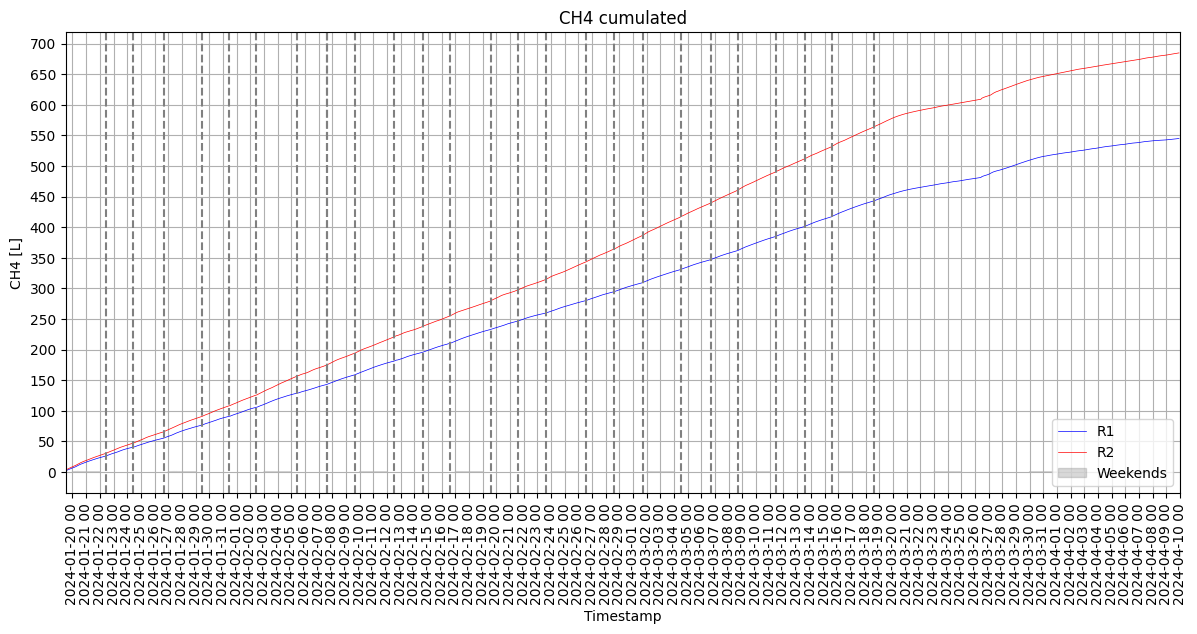

684.6950437500659
544.8934550000546


In [15]:
#METHANE CUMULATIVE
import matplotlib.dates as mdates
# Plot the overall time series
plt.figure(figsize=(12, 6))
plt.plot(R1['Timestamp'], R1['ch4_cum'], color='b', label='R1',linewidth=0.5)  # Replace 'variable_name' with your actual variable name
plt.plot(R2['Timestamp'], R2['ch4_cum'], color='r', label='R2',linewidth=0.5)
#plt.plot(R1['Timestamp'], R1['1F1.2 [L]'], color='black', label='R1_signal',linewidth=0.5)
#plt.plot(R1['Timestamp'], R1['gas_cum'], color='g', label='R1_calc',linewidth=0.5)

# Highlight weekends with grey color based on the timestamp column
weekend_mask = (R1['Timestamp'].dt.weekday >= 5)  # Saturday and Sunday
plt.fill_between(R1['Timestamp'], 0, R1['ch4_rate_moving_average'], where=weekend_mask, color='grey', alpha=0.3, label='Weekends')

for time_instant in specific_time_instants:
    plt.axvline(pd.to_datetime(time_instant), color='grey', linestyle='dashed')#, label=f'{time_instant}')

plt.xlabel('Timestamp')
plt.ylabel('CH4 [L]')
plt.title('CH4 cumulated')
plt.legend()
plt.xticks(rotation=90)
#Select one of the two following to increase y-axis grid 
#plt.yticks(np.arange(0, 250, 20))
plt.locator_params(axis='y', nbins=20)
plt.tight_layout()
ax = plt.gca()
#ax.set_xlim([xmin, xmax])
#ax.set_ylim([0, 5])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

# Set x-axis limits with timestamps (from 10:30 AM to 12:30 PM)
start_time = datetime(2024, 1, 19, 12, 0)
end_time = datetime(2024, 4, 10, 0, 0)

plt.xlim(mdates.date2num(start_time), mdates.date2num(end_time))
ax = plt.gca()
#ax.set_ylim([400, 420])
#ax.set_xlim([200,500])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d %H')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.HourLocator(interval=24))

plt.grid(True)
plt.show()

#Last value
print(R2['ch4_cum'].iloc[-1])
print(R1['ch4_cum'].iloc[-1])

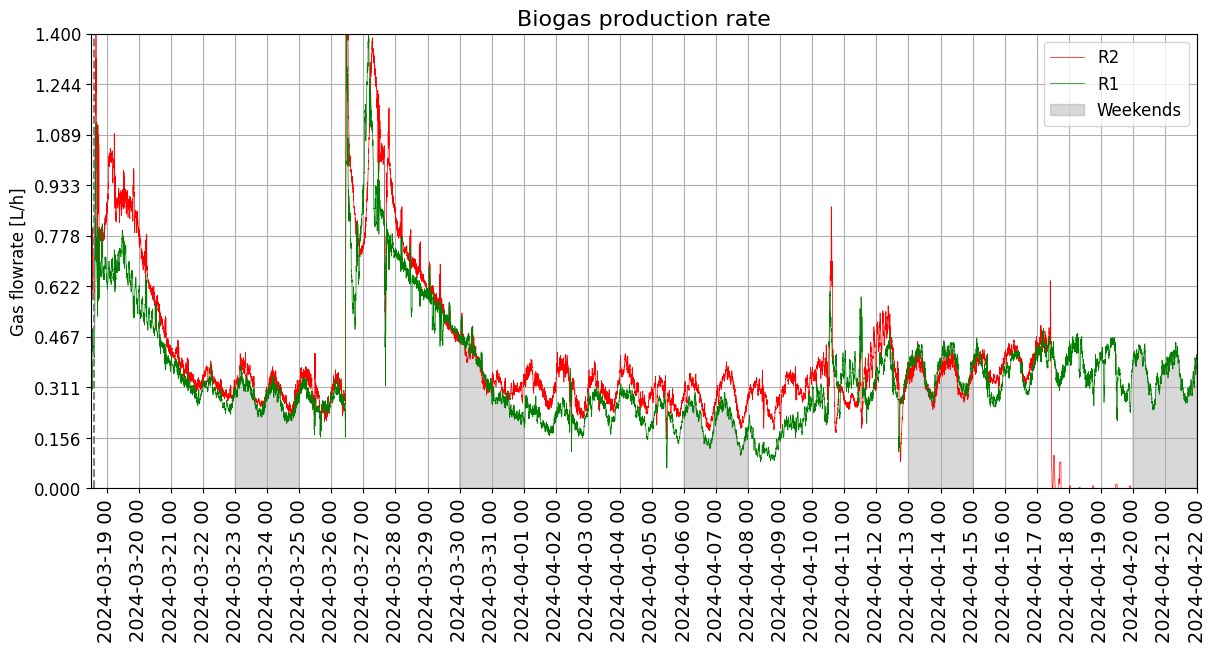

In [60]:
#GAS FLOWRATE
import matplotlib.dates as mdates
from matplotlib.dates import date2num
mpl_dates = pd.to_datetime(setpoint_data['Timestamp'])
# Plot the overall time series
plt.figure(figsize=(12, 6))
plt.plot(R2['Timestamp'], R2['rate_moving_average'], color='r', label='R2',linewidth=0.5)
plt.plot(R1['Timestamp'], R1['rate_moving_average'], color='g', label='R1',linewidth=0.5)

# Highlight weekends with grey color based on the timestamp column
weekend_mask = (R1['Timestamp'].dt.weekday >= 5)  # Saturday and Sunday
plt.fill_between(R1['Timestamp'], 0, R1['rate_moving_average'], where=weekend_mask, color='grey', alpha=0.3, label='Weekends')

for time_instant in specific_time_instants:
    plt.axvline(pd.to_datetime(time_instant), color='grey', linestyle='dashed')#, label=f'{time_instant}')

#plt.xlabel('Timestamp')
plt.ylabel('Gas flowrate [L/h]',fontsize=12)
plt.title('Biogas production rate', fontsize=16)
plt.legend(fontsize=12)
plt.xticks(rotation=90, fontsize=14)
plt.tight_layout()
ax = plt.gca()
#ax.set_xlim([xmin, xmax])
#ax.set_ylim([0, 5])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))

# Set x-axis limits with timestamps (from 10:30 AM to 12:30 PM)
start_time = datetime(2024, 3, 18, 12, 0)
end_time = datetime(2024, 4, 22, 0, 0)

plt.xlim(mdates.date2num(start_time), mdates.date2num(end_time))
ax = plt.gca()
#ax.set_ylim([42, 42.4])
#ax.set_xlim([15000,15015])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d %H')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.HourLocator(interval=24))

# Specify the number of ticks on the y-axis
num_ticks = 10  # Adjust this value as needed

# Calculate tick positions based on the number of ticks
min_value = 0
max_value = 1.4
ax.set_ylim([min_value, max_value])
y_ticks = [min_value + i * ((max_value - min_value) / (num_ticks - 1)) for i in range(num_ticks)]

# Set the ticks on the y-axis
plt.yticks(y_ticks,fontsize=12)

plt.grid()
plt.show()

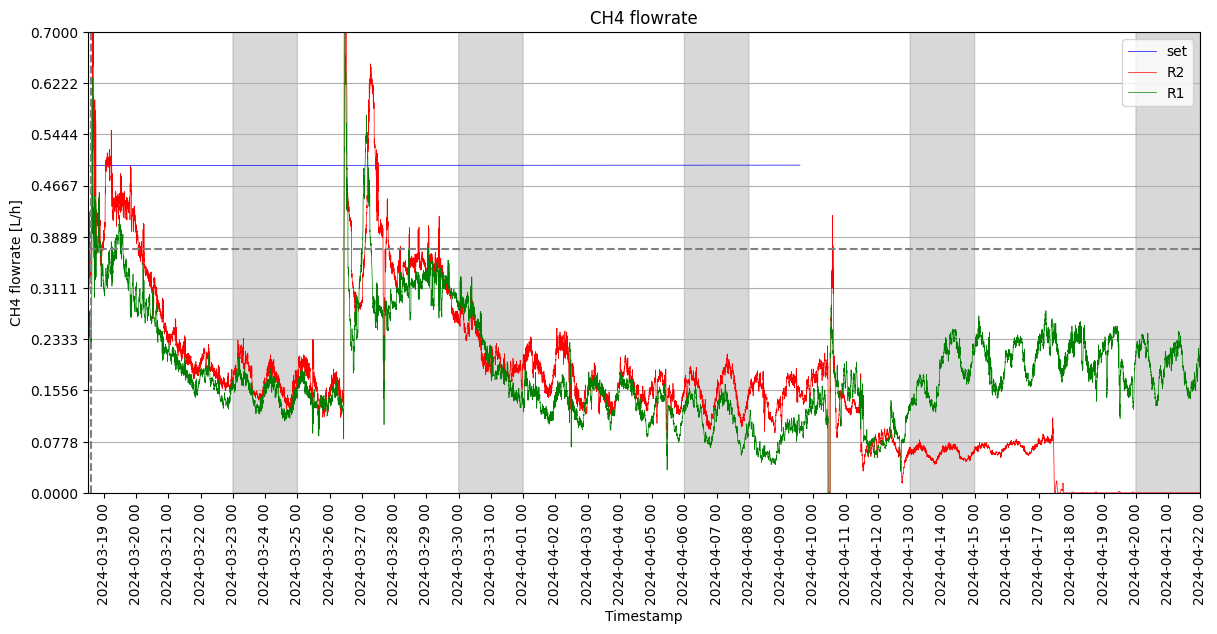

In [61]:
#METHANE FLOWRATE
import matplotlib.dates as mdates
from matplotlib.dates import date2num
mpl_dates = pd.to_datetime(setpoint_data['Timestamp'])
# Plot the overall time series
plt.figure(figsize=(12, 6))
plt.plot(mpl_dates, setpoint_data['Setpoint1']+0.057, color='b', label='set',linewidth=0.5)  # Replace 'variable_name' with your actual variable name
plt.plot(R2['Timestamp'], R2['ch4_rate_moving_average'], color='r', label='R2',linewidth=0.5)
plt.plot(R1['Timestamp'], R1['ch4_rate_moving_average'], color='g', label='R1',linewidth=0.5)

for time_instant in specific_time_instants:
    plt.axvline(pd.to_datetime(time_instant), color='grey', linestyle='dashed')#, label=f'{time_instant}')

plt.axhline(0.37, color='grey', linestyle='dashed')#, label=f'{time_instant}')
plt.xlabel('Timestamp')
plt.ylabel('CH4 flowrate [L/h]')
title = 'CH4 flowrate'
plt.title(title)
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
ax = plt.gca()
#ax.set_xlim([xmin, xmax])
#ax.set_ylim([0, 5])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

# Set x-axis limits with timestamps (from 10:30 AM to 12:30 PM)
start_time = datetime(2024, 3, 18, 12, 0)
end_time = datetime(2024, 4, 22, 0, 0)

plt.xlim(mdates.date2num(start_time), mdates.date2num(end_time))
ax = plt.gca()
#ax.set_ylim([42, 42.4])
#ax.set_xlim([15000,15015])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d %H')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.HourLocator(interval=24))

# Specify the number of ticks on the y-axis
num_ticks = 10  # Adjust this value as needed

# Calculate tick positions based on the number of ticks
min_value = 0
max_value = 0.7
ax.set_ylim([min_value, max_value])
y_ticks = [min_value + i * ((max_value - min_value) / (num_ticks - 1)) for i in range(num_ticks)]

# Set the ticks on the y-axis
plt.yticks(y_ticks)

# Highlight weekends with grey color based on the timestamp column
weekend_mask = (R1['Timestamp'].dt.weekday >= 5)  # Saturday and Sunday
plt.fill_between(R1['Timestamp'], 0, max_value, where=weekend_mask, color='grey', alpha=0.3, label='Weekends')

plt.grid(axis='y')

# Specify the directory to save the figure
save_directory = 'C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Sperimentazione UIT/Software/'

# Save the plot to the specified directory with a desired filename
#plt.savefig(save_directory + f'{title}_{current_date}.png')

plt.show()

In [ ]:
# CARBON DIOXIDE
import matplotlib.dates as mdates
from matplotlib.dates import date2num
mpl_dates = pd.to_datetime(setpoint_data['Timestamp'])
# Plot the overall time series
plt.figure(figsize=(12, 6))
plt.plot(R2['Timestamp'], R2['co2_rate_moving_average'], color='r', label='R2',linewidth=0.5)
plt.plot(R1['Timestamp'], R1['co2_rate_moving_average'], color='g', label='R1',linewidth=0.5)

for time_instant in specific_time_instants:
    plt.axvline(pd.to_datetime(time_instant), color='grey', linestyle='dashed')#, label=f'{time_instant}')

plt.axhline(0.37, color='grey', linestyle='dashed')#, label=f'{time_instant}')
plt.xlabel('Timestamp')
plt.ylabel('CO2 flowrate [L/h]')
title = 'CO2 flowrate'
plt.title(title)
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
ax = plt.gca()
#ax.set_xlim([xmin, xmax])
#ax.set_ylim([0, 5])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

# Set x-axis limits with timestamps (from 10:30 AM to 12:30 PM)
start_time = datetime(2024, 1, 19, 12, 0)
end_time = datetime(2024, 3, 19, 0, 0)

plt.xlim(mdates.date2num(start_time), mdates.date2num(end_time))
ax = plt.gca()
#ax.set_ylim([42, 42.4])
#ax.set_xlim([15000,15015])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d %H')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.HourLocator(interval=24))

# Specify the number of ticks on the y-axis
num_ticks = 10  # Adjust this value as needed

# Calculate tick positions based on the number of ticks
min_value = 0
max_value = 0.7
ax.set_ylim([min_value, max_value])
y_ticks = [min_value + i * ((max_value - min_value) / (num_ticks - 1)) for i in range(num_ticks)]

# Set the ticks on the y-axis
plt.yticks(y_ticks)

# Highlight weekends with grey color based on the timestamp column
weekend_mask = (R1['Timestamp'].dt.weekday >= 5)  # Saturday and Sunday
plt.fill_between(R1['Timestamp'], 0, max_value, where=weekend_mask, color='grey', alpha=0.3, label='Weekends')

plt.grid(axis='y')

# Specify the directory to save the figure
save_directory = 'C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Sperimentazione UIT/Software/'

# Save the plot to the specified directory with a desired filename
#plt.savefig(save_directory + f'{title}_{current_date}_prepost.png')

plt.show()

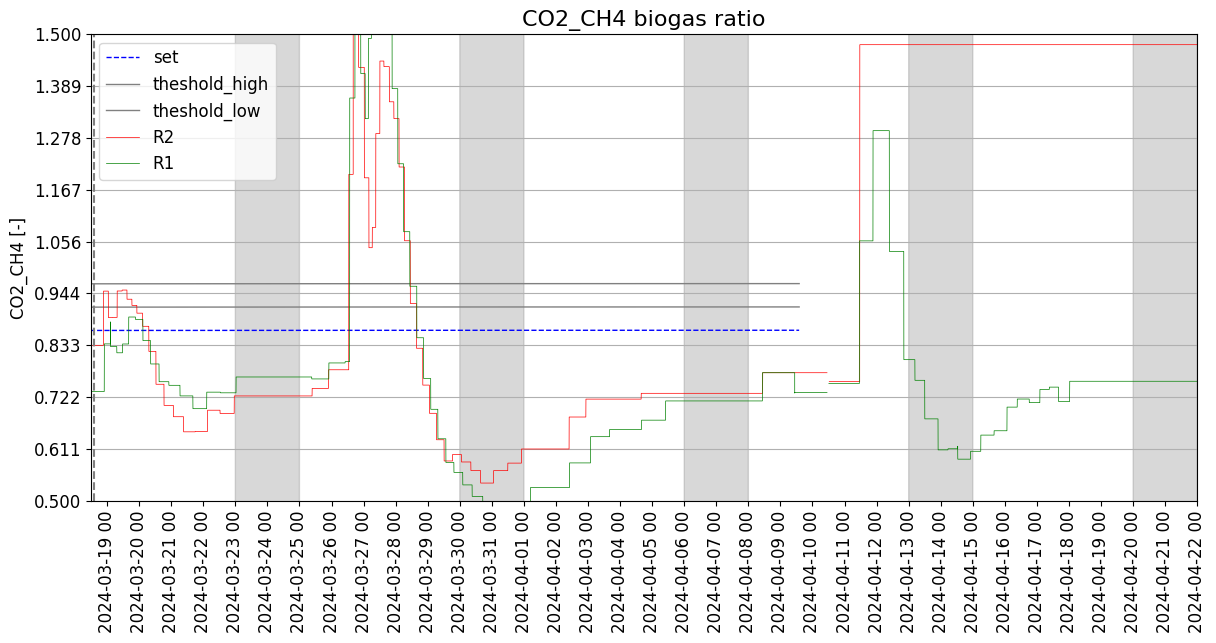

In [62]:
# GAS RATIO
import matplotlib.dates as mdates
from matplotlib.dates import date2num
mpl_dates = pd.to_datetime(setpoint_data['Timestamp'])
# Plot the overall time series
plt.figure(figsize=(12, 6))
plt.plot(mpl_dates, setpoint_data['Setpoint2']+0.019, color='b', label='set',linewidth=1,linestyle='dashed')  # Replace 'variable_name' with your actual variable name
plt.plot(mpl_dates, setpoint_data['Setpoint2']+0.019+0.1, color='grey', label='theshold_high',linewidth=1)  # Replace 'variable_name' with your actual variable name
plt.plot(mpl_dates, setpoint_data['Setpoint2']+0.019+0.05, color='grey', label='theshold_low',linewidth=1)  # Replace 'variable_name' with your actual variable name
plt.plot(R2['Timestamp'], 1/R2['gas_ratio'], color='r', label='R2',linewidth=0.5)
plt.plot(R1['Timestamp'], 1/R1['gas_ratio'], color='g', label='R1',linewidth=0.5)

for time_instant in specific_time_instants:
    plt.axvline(pd.to_datetime(time_instant), color='grey', linestyle='dashed')#, label=f'{time_instant}')

#plt.xlabel('Timestamp')
plt.ylabel('CO2_CH4 [-]',fontsize=12)
title = 'CO2_CH4 biogas ratio'
plt.title(title,fontsize=16)
plt.legend(fontsize=12)
plt.xticks(rotation=90,fontsize=12)
plt.tight_layout()
ax = plt.gca()
#ax.set_xlim([xmin, xmax])
#ax.set_ylim([0, 5])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))

# Set x-axis limits with timestamps (from 10:30 AM to 12:30 PM)
start_time = datetime(2024, 3, 18, 12, 0)
end_time = datetime(2024, 4, 22, 0, 0)

plt.xlim(mdates.date2num(start_time), mdates.date2num(end_time))
ax = plt.gca()
#ax.set_ylim([42, 42.4])
#ax.set_xlim([15000,15015])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d %H')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.HourLocator(interval=24))

# Specify the number of ticks on the y-axis
num_ticks = 10  # Adjust this value as needed

# Calculate tick positions based on the number of ticks
min_value = 0.5
max_value = 1.5
ax.set_ylim([min_value, max_value])
y_ticks = [min_value + i * ((max_value - min_value) / (num_ticks - 1)) for i in range(num_ticks)]

# Set the ticks on the y-axis
plt.yticks(y_ticks)
plt.yticks(fontsize=12)

# Highlight weekends with grey color based on the timestamp column
weekend_mask = (R1['Timestamp'].dt.weekday >= 5)  # Saturday and Sunday
plt.fill_between(R1['Timestamp'], 0, max_value, where=weekend_mask, color='grey', alpha=0.3, label='Weekends')

plt.grid(axis = 'y')

# Specify the directory to save the figure
save_directory = 'C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Sperimentazione UIT/Software/'

# Save the plot to the specified directory with a desired filename
#plt.savefig(save_directory + f'{title}_{current_date}.png')

plt.show()

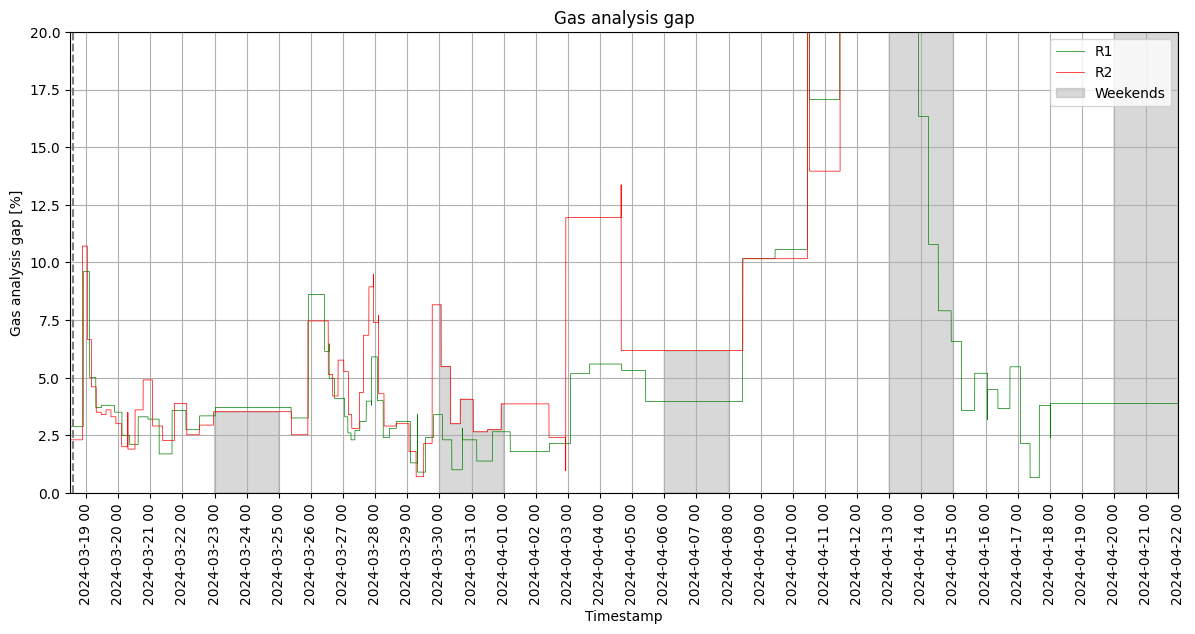

In [63]:
# DELTA GAS
import matplotlib.dates as mdates
# Plot the overall time series
plt.figure(figsize=(12, 6))
plt.plot(R1['Timestamp'], 100-R1['1X11Q1 [V% O2]']-R1['1X11Q2 [V% CO2]']-R1['1X11Q3 [V% CH4]'], color='g', label='R1',linewidth=0.5)  # Replace 'variable_name' with your actual variable name
plt.plot(R2['Timestamp'], 100-R2['2X11Q1 [V% O2]']-R2['2X11Q2 [V% CO2]']-R2['2X11Q3 [V% CH4]'], color='r', label='R2',linewidth=0.5)

# Highlight weekends with grey color based on the timestamp column
# Highlight weekends with grey color based on the timestamp column
weekend_mask = (R2['Timestamp'].dt.weekday >= 5)  # Saturday and Sunday
plt.fill_between(R2['Timestamp'], 0, 100-R2['2X11Q1 [V% O2]']-R2['2X11Q2 [V% CO2]']-R2['2X11Q3 [V% CH4]'], where=weekend_mask, color='grey', alpha=0.3, label='Weekends')

for time_instant in specific_time_instants:
    plt.axvline(pd.to_datetime(time_instant), color='grey', linestyle='dashed')#, label=f'{time_instant}')

plt.xlabel('Timestamp')
plt.ylabel('Gas analysis gap [%]')
plt.title('Gas analysis gap')
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
ax = plt.gca()
#ax.set_xlim([xmin, xmax])
ax.set_ylim([0, 20])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

# Set x-axis limits with timestamps (from 10:30 AM to 12:30 PM)
start_time = datetime(2024, 3, 18, 12, 0)
end_time = datetime(2024, 4, 22, 0, 0)

plt.xlim(mdates.date2num(start_time), mdates.date2num(end_time))
ax = plt.gca()
#ax.set_ylim([42, 42.4])
#ax.set_xlim([15000,15015])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d %H')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.HourLocator(interval=24))

plt.grid()
plt.show()

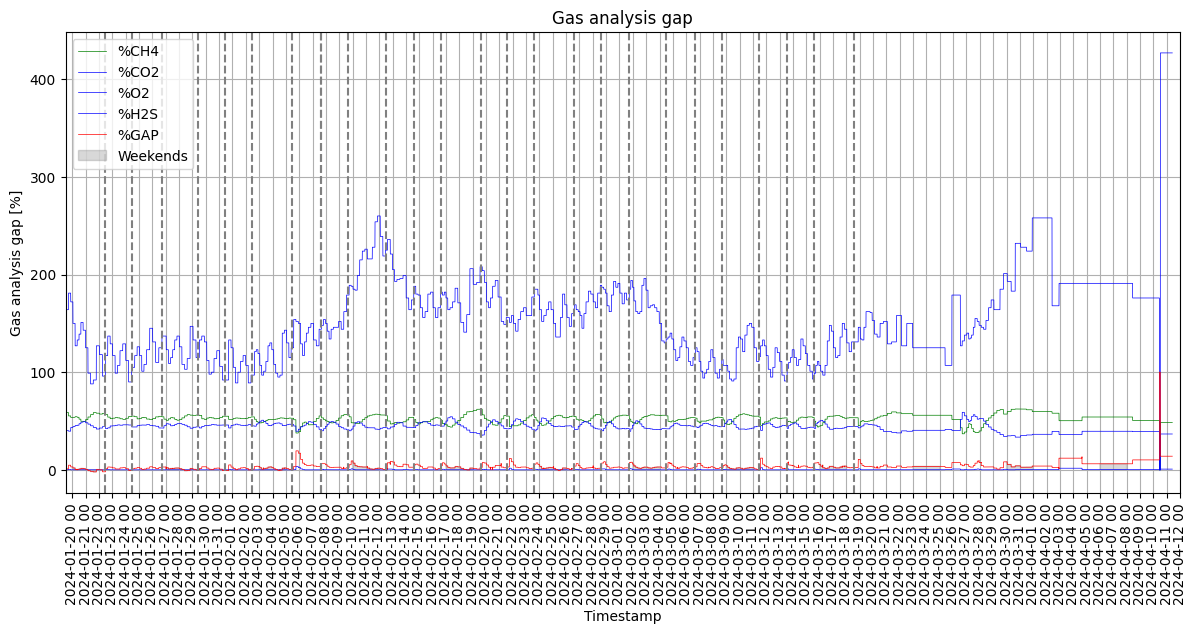

In [44]:
# DELTA GAS R2
import matplotlib.dates as mdates
# Plot the overall time series
plt.figure(figsize=(12, 6))
#plt.plot(R1['Timestamp'], 100-R1['1X11Q1 [V% O2]']-R1['1X11Q2 [V% CO2]']-R1['1X11Q3 [V% CH4]'], color='g', label='R1',linewidth=0.5)  # Replace 'variable_name' with your actual variable name
plt.plot(R2['Timestamp'], R2['2X11Q3 [V% CH4]'], color='g', label='%CH4',linewidth=0.5)  # Replace 'variable_name' with your actual variable name
plt.plot(R2['Timestamp'], R2['2X11Q2 [V% CO2]'], color='b', label='%CO2',linewidth=0.5)  # Replace 'variable_name' with your actual variable name
plt.plot(R2['Timestamp'], R2['2X11Q1 [V% O2]'], color='b', label='%O2',linewidth=0.5)  # Replace 'variable_name' with your actual variable name
plt.plot(R2['Timestamp'], R2['2X11Q4 [ppm H2S]'], color='b', label='%H2S',linewidth=0.5)  # Replace 'variable_name' with your actual variable name
plt.plot(R2['Timestamp'], 100-R2['2X11Q1 [V% O2]']-R2['2X11Q2 [V% CO2]']-R2['2X11Q3 [V% CH4]'], color='r', label='%GAP',linewidth=0.5)

# Highlight weekends with grey color based on the timestamp column
# Highlight weekends with grey color based on the timestamp column
weekend_mask = (R2['Timestamp'].dt.weekday >= 5)  # Saturday and Sunday
plt.fill_between(R2['Timestamp'], 0, 100-R2['2X11Q1 [V% O2]']-R2['2X11Q2 [V% CO2]']-R2['2X11Q3 [V% CH4]'], where=weekend_mask, color='grey', alpha=0.3, label='Weekends')

for time_instant in specific_time_instants:
    plt.axvline(pd.to_datetime(time_instant), color='grey', linestyle='dashed')#, label=f'{time_instant}')

plt.xlabel('Timestamp')
plt.ylabel('Gas analysis gap [%]')
plt.title('Gas analysis gap')
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
ax = plt.gca()
#ax.set_xlim([xmin, xmax])
#ax.set_ylim([0, 20])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

# Set x-axis limits with timestamps (from 10:30 AM to 12:30 PM)
start_time = datetime(2024, 1, 19, 12, 0)
end_time = datetime(2024, 4, 12, 0, 0)

plt.xlim(mdates.date2num(start_time), mdates.date2num(end_time))
ax = plt.gca()
#ax.set_ylim([42, 42.4])
#ax.set_xlim([15000,15015])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d %H')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.HourLocator(interval=24))

plt.grid()
plt.show()

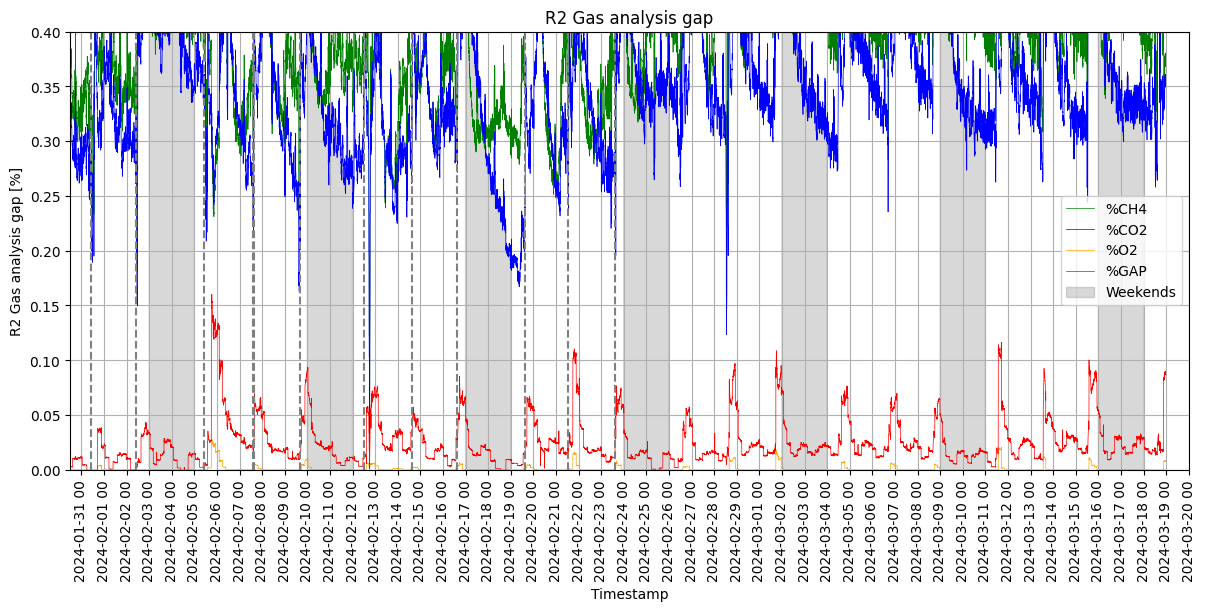

In [35]:
# DELTA GAS
import matplotlib.dates as mdates
# Plot the overall time series
plt.figure(figsize=(12, 6))
reactor = '2'
df = R2
plt.plot(df['Timestamp'], df['rate_moving_average']*df[f'{reactor}X11Q3 [V% CH4]']/100, color='g', label='%CH4',linewidth=0.5)  # Replace 'variable_name' with your actual variable name
plt.plot(df['Timestamp'], df['rate_moving_average']*df[f'{reactor}X11Q2 [V% CO2]']/100, color='b', label='%CO2',linewidth=0.5)  # Replace 'variable_name' with your actual variable name
plt.plot(df['Timestamp'], df['rate_moving_average']*df[f'{reactor}X11Q1 [V% O2]']/100, color='orange', label='%O2',linewidth=0.5)  # Replace 'variable_name' with your actual variable name
plt.plot(df['Timestamp'], df['rate_moving_average']*(100-df[f'{reactor}X11Q1 [V% O2]']-df[f'{reactor}X11Q2 [V% CO2]']-df[f'{reactor}X11Q3 [V% CH4]'])/100, color='r', label='%GAP',linewidth=0.5)

# Highlight weekends with grey color based on the timestamp column
# Highlight weekends with grey color based on the timestamp column
weekend_mask = (df['Timestamp'].dt.weekday >= 5)  # Saturday and Sunday
plt.fill_between(df['Timestamp'], 0, df['rate_moving_average']*df[f'{reactor}X11Q2 [V% CO2]']/100, where=weekend_mask, color='grey', alpha=0.3, label='Weekends')

# Add vertical dotted lines at specific time instants
specific_time_instants = ['2023-11-10 12:30' ,'2023-11-13 12:30', '2023-11-15 12:30', 
                          '2023-11-17 12:30', '2023-11-20 12:30', '2023-11-22 12:30', 
                          '2023-11-24 12:30', '2023-11-27 12:30', '2023-11-29 12:30',
                          '2023-12-1 14:30', '2023-12-4 16:00', '2023-12-6 12:00',
                         '2023-12-8 13:30','2023-12-11 13:30','2023-12-13 13:30',
                          '2023-12-15 13:30','2023-12-18 13:30','2023-12-20 13:30','2023-12-22 15:30',
                          '2024-1-8 10:30','2024-1-10 10:30','2024-1-12 10:30','2024-1-15 10:30',
                         '2024-1-17 10:30','2024-1-19 10:30','2024-1-22 10:30','2024-1-24 10:30',
                          '2024-1-26 16:30','2024-1-29 10:30','2024-1-31 10:30','2024-2-2 10:30',
                          '2024-2-5 10:30','2024-2-7 14:30','2024-2-7 15:00','2024-2-9 16:15',
                          '2024-2-12 11:45','2024-2-14 15:00','2024-2-16 15:00','2024-2-19 15:00',
                          '2024-2-21 13:15','2024-2-23 15:00'
                         ]
for time_instant in specific_time_instants:
    plt.axvline(pd.to_datetime(time_instant), color='grey', linestyle='dashed')#, label=f'{time_instant}')

plt.xlabel('Timestamp')
plt.ylabel(f'R{reactor} Gas analysis gap [%]')
title = f'R{reactor} Gas analysis gap'
plt.title(title)
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
ax = plt.gca()
#ax.set_xlim([xmin, xmax])
ax.set_ylim([0, 1])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

# Set x-axis limits with timestamps (from 10:30 AM to 12:30 PM)
start_time = datetime(2024, 1, 30, 12, 0)
end_time = datetime(2024, 3, 20, 0, 0)

plt.xlim(mdates.date2num(start_time), mdates.date2num(end_time))
ax = plt.gca()
ax.set_ylim([0, 0.4])
#ax.set_xlim([15000,15015])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d %H')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.HourLocator(interval=24))

plt.grid()

# Specify the directory to save the figure
save_directory = 'C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Sperimentazione UIT/Software/'

# Save the plot to the specified directory with a desired filename
#plt.savefig(save_directory + f'{title}_{current_date}_prepost.png')

plt.show()

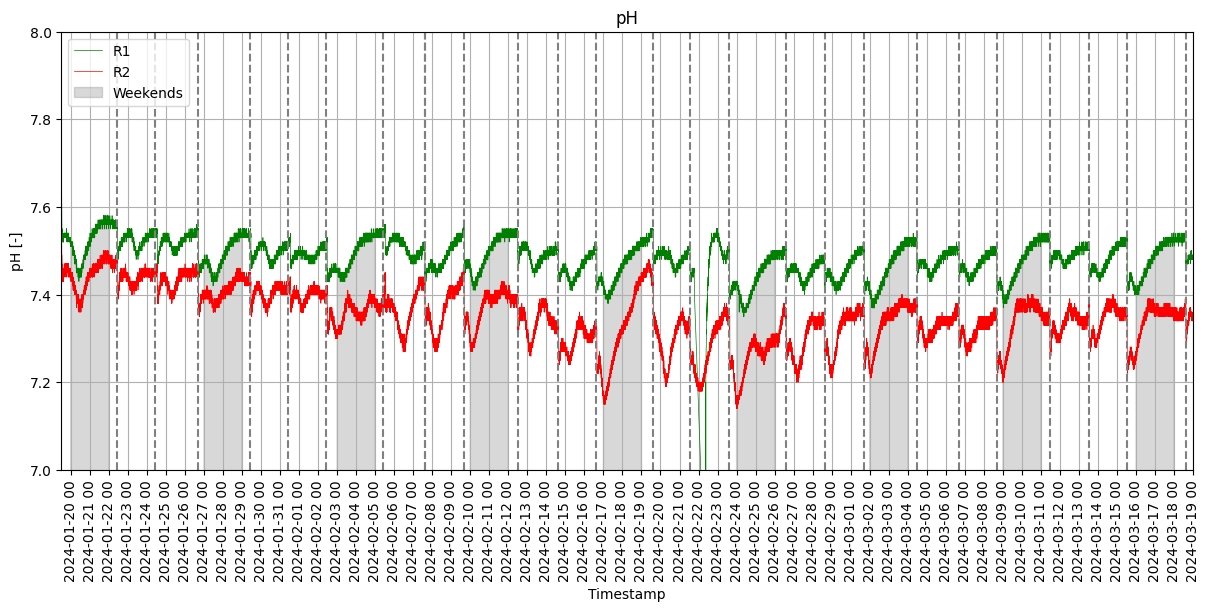

In [49]:
# PH
import matplotlib.dates as mdates
# Plot the overall time series
plt.figure(figsize=(12, 6))
plt.plot(R1['Timestamp'], R1['1Q1 [pH]_out'], color='g', label='R1',linewidth=0.5)  # Replace 'variable_name' with your actual variable name
plt.plot(R2['Timestamp'], R2['2Q1 [pH]_out'], color='r', label='R2',linewidth=0.5)

# Highlight weekends with grey color based on the timestamp column
# Highlight weekends with grey color based on the timestamp column
weekend_mask = (R1['Timestamp'].dt.weekday >= 5)  # Saturday and Sunday
plt.fill_between(R1['Timestamp'], 0, R1['1Q1 [pH]_out'], where=weekend_mask, color='grey', alpha=0.3, label='Weekends')

for time_instant in specific_time_instants:
    plt.axvline(pd.to_datetime(time_instant), color='grey', linestyle='dashed')#, label=f'{time_instant}')

plt.xlabel('Timestamp')
plt.ylabel('pH [-]')
title = 'pH'
plt.title(title)
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
ax = plt.gca()
#ax.set_xlim([xmin, xmax])
ax.set_ylim([7, 8])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

# Set x-axis limits with timestamps (from 10:30 AM to 12:30 PM)
start_time = datetime(2024, 1, 19, 12, 0)
end_time = datetime(2024, 3, 19, 0, 0)

plt.xlim(mdates.date2num(start_time), mdates.date2num(end_time))
ax = plt.gca()
#ax.set_ylim([42, 42.4])
#ax.set_xlim([15000,15015])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d %H')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.HourLocator(interval=24))

plt.grid()

# Specify the directory to save the figure
save_directory = 'C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Sperimentazione UIT/Software/'

# Save the plot to the specified directory with a desired filename
#plt.savefig(save_directory + f'{title}_{current_date}_prepost.png')

plt.show()

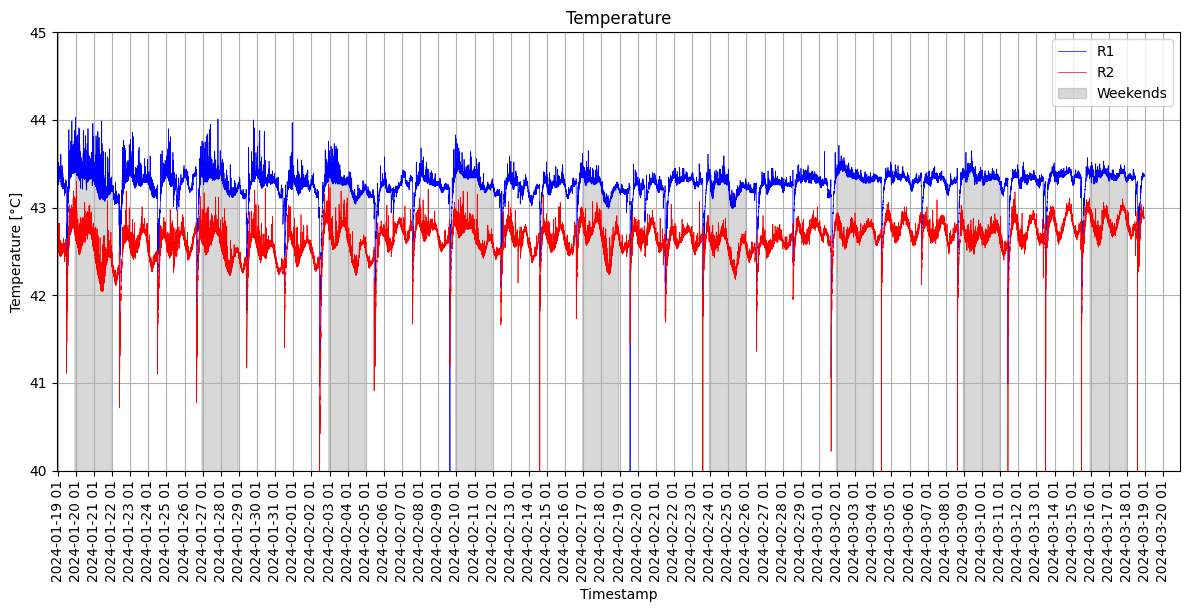

In [38]:
# TEMPERATURE
import matplotlib.dates as mdates
# Plot the overall time series
plt.figure(figsize=(12, 6))
plt.plot(R1['Timestamp'], R1['1T1 [°C]'], color='b', label='R1',linewidth=0.5)  # Replace 'variable_name' with your actual variable name
plt.plot(R2['Timestamp'], R2['2T1 [°C]'], color='r', label='R2',linewidth=0.5)

# Highlight weekends with grey color based on the timestamp column
weekend_mask = (R1['Timestamp'].dt.weekday >= 5)  # Saturday and Sunday
plt.fill_between(R1['Timestamp'], 0, R1['1T1 [°C]'], where=weekend_mask, color='grey', alpha=0.3, label='Weekends')

# Add vertical dotted lines at specific time instants
specific_time_instants = ['2023-11-10 12:30' ,'2023-11-13 12:30', '2023-11-15 12:30', 
                          '2023-11-17 12:30', '2023-11-20 12:30', '2023-11-22 12:30', 
                          '2023-11-24 12:30', '2023-11-27 12:30', '2023-11-29 12:30',
                          '2023-12-1 14:30', '2023-12-4 16:00', '2023-12-6 12:00',
                         '2023-12-8 13:30','2023-12-11 13:30','2023-12-13 13:30',
                          '2023-12-15 13:30','2023-12-18 13:30','2023-12-20 13:30','2023-12-22 15:30']
for time_instant in specific_time_instants:
    plt.axvline(pd.to_datetime(time_instant), color='grey', linestyle='dashed')#, label=f'{time_instant}')

plt.xlabel('Timestamp')
plt.ylabel('Temperature [°C]')
plt.title('Temperature')
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
ax = plt.gca()
#ax.set_xlim([xmin, xmax])
ax.set_ylim([40, 45])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

# Set x-axis limits with timestamps (from 10:30 AM to 12:30 PM)
start_time = datetime(2024, 1, 19, 0, 0)
end_time = datetime(2024, 3, 20, 23, 0)

plt.xlim(mdates.date2num(start_time), mdates.date2num(end_time))
ax = plt.gca()
#ax.set_ylim([42, 42.4])
#ax.set_xlim([15000,15015])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d %H')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.HourLocator(interval=24))

plt.grid()
plt.show()

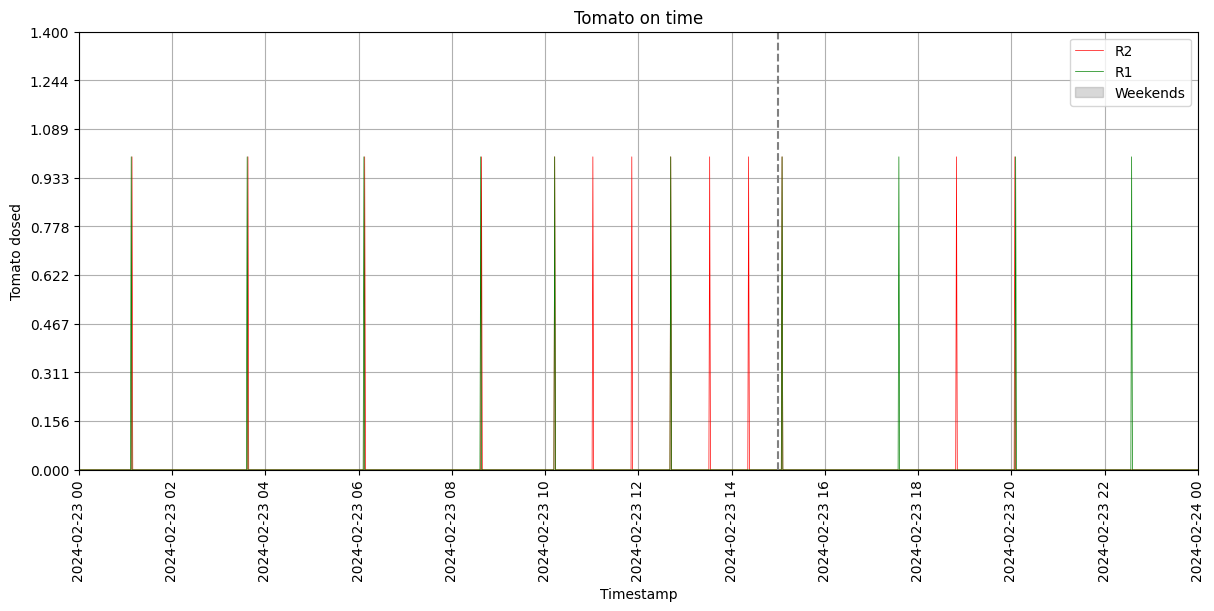

In [380]:
# Check when the pumps are actually turned on
import matplotlib.dates as mdates
from matplotlib.dates import date2num
# Plot the overall time series
plt.figure(figsize=(12, 6))
plt.plot(R2['Timestamp'], R2['2P4'], color='r', label='R2',linewidth=0.5)
plt.plot(R1['Timestamp'], R1['1P4'], color='g', label='R1',linewidth=0.5)

# Highlight weekends with grey color based on the timestamp column
weekend_mask = (R2['Timestamp'].dt.weekday >= 5)  # Saturday and Sunday
plt.fill_between(R2['Timestamp'], 0, R2['2P4'], where=weekend_mask, color='grey', alpha=0.3, label='Weekends')

# Add vertical dotted lines at specific time instants
specific_time_instants = ['2023-11-10 12:30' ,'2023-11-13 12:30', '2023-11-15 12:30', 
                          '2023-11-17 12:30', '2023-11-20 12:30', '2023-11-22 12:30', 
                          '2023-11-24 12:30', '2023-11-27 12:30', '2023-11-29 12:30',
                          '2023-12-1 14:30', '2023-12-4 16:00', '2023-12-6 12:00',
                         '2023-12-8 13:30','2023-12-11 13:30','2023-12-13 13:30',
                          '2023-12-15 13:30','2023-12-18 13:30','2023-12-20 13:30','2023-12-22 15:30',
                          '2024-1-8 10:30','2024-1-10 10:30','2024-1-12 10:30','2024-1-15 10:30',
                         '2024-1-17 10:30','2024-1-19 10:30','2024-1-22 10:30','2024-1-24 10:30',
                          '2024-1-26 16:30','2024-1-29 10:30','2024-1-31 10:30','2024-2-2 10:30',
                          '2024-2-5 10:30','2024-2-7 14:30','2024-2-7 15:00','2024-2-9 16:15',
                          '2024-2-12 11:45','2024-2-14 15:00','2024-2-16 15:00','2024-2-19 15:00',
                          '2024-2-21 13:15','2024-2-23 15:00'
                         ]
for time_instant in specific_time_instants:
    plt.axvline(pd.to_datetime(time_instant), color='grey', linestyle='dashed')#, label=f'{time_instant}')

plt.xlabel('Timestamp')
plt.ylabel('Tomato dosed')
plt.title('Tomato on time')
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
ax = plt.gca()
#ax.set_xlim([xmin, xmax])
#ax.set_ylim([0, 5])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

# Set x-axis limits with timestamps (from 10:30 AM to 12:30 PM)
start_time = datetime(2024, 2, 23, 0, 0)
end_time = datetime(2024, 2, 24, 0, 0)

plt.xlim(mdates.date2num(start_time), mdates.date2num(end_time))
ax = plt.gca()
#ax.set_ylim([42, 42.4])
#ax.set_xlim([15000,15015])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d %H')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))

# Specify the number of ticks on the y-axis
num_ticks = 10  # Adjust this value as needed

# Calculate tick positions based on the number of ticks
min_value = 0
max_value = 1.4
ax.set_ylim([min_value, max_value])
y_ticks = [min_value + i * ((max_value - min_value) / (num_ticks - 1)) for i in range(num_ticks)]

# Set the ticks on the y-axis
plt.yticks(y_ticks)

plt.grid()
plt.show()

In [ ]:
# CALCS -----------------------------------------------------------------------------------------------------------------------

In [64]:
#Mean over a specific interval of datetimes
start_time = datetime(2024, 1, 19, 12, 0)
end_time = datetime(2024, 1, 30, 12, 0)
# Compute the mean
filtered_df = R2[(R2['Timestamp'] >= start_time) & (R2['Timestamp'] <= end_time)]
mean_value = filtered_df['ch4_rate_moving_average'].mean()
std_dev_value  = filtered_df['ch4_rate_moving_average'].std()

# Print the mean value
print(f"The mean value between {start_time} and {end_time} is: {mean_value}")
print(f"The st.dev value between {start_time} and {end_time} is: {std_dev_value}")

The mean value between 2024-01-19 12:00:00 and 2024-01-30 12:00:00 is: 0.36779315781981525
The st.dev value between 2024-01-19 12:00:00 and 2024-01-30 12:00:00 is: 0.06179191772615543


In [23]:
# Computation of dosed tomato
COD_VS_tomato = 1.3
# Convert 'timestamp' to datetime if it's not already in datetime format
R2['Timestamp'] = pd.to_datetime(R2['Timestamp'])

# Group by day and calculate the sum for each group
on_minutes_tot_daily_sum_R2 = R2.groupby(R2['Timestamp'].dt.date)['2P4'].sum().reset_index()
on_minutes_tot_daily_sum_R2['2P4'] = on_minutes_tot_daily_sum_R2['2P4']*10 #mL/day
on_minutes_tot_daily_sum_R2['COD_tomato_R2'] = on_minutes_tot_daily_sum_R2['2P4']*COD_VS_tomato/1000

on_minutes_tot_daily_sum_R1 = R1.groupby(R1['Timestamp'].dt.date)['1P4'].sum().reset_index()
on_minutes_tot_daily_sum_R1['1P4'] = on_minutes_tot_daily_sum_R1['1P4']*10 #mL/day
on_minutes_tot_daily_sum_R1['COD_tomato_R1'] = on_minutes_tot_daily_sum_R1['1P4']*COD_VS_tomato/1000

result_combined = pd.concat([on_minutes_tot_daily_sum_R2, on_minutes_tot_daily_sum_R1], axis=1)

column_names = ['TimestampR2','Tomato R2 [mL/day]','COD_tomato_R2','TimestampR1','Tomato R1 [mL/day]','COD_tomato_R1']
result_combined.columns = column_names

# Print the resulting DataFrame
print(result_combined)

   TimestampR2  Tomato R2 [mL/day]  COD_tomato_R2 TimestampR1  \
0   2024-01-19                80.0          0.104  2024-01-19   
1   2024-01-20                90.0          0.117  2024-01-20   
2   2024-01-21                90.0          0.117  2024-01-21   
3   2024-01-22                90.0          0.117  2024-01-22   
4   2024-01-23                90.0          0.117  2024-01-23   
5   2024-01-24               100.0          0.130  2024-01-24   
6   2024-01-25                90.0          0.117  2024-01-25   
7   2024-01-26               100.0          0.130  2024-01-26   
8   2024-01-27               100.0          0.130  2024-01-27   
9   2024-01-28                90.0          0.117  2024-01-28   
10  2024-01-29               100.0          0.130  2024-01-29   
11  2024-01-30               100.0          0.130  2024-01-30   
12  2024-01-31               100.0          0.130  2024-01-31   
13  2024-02-01                90.0          0.117  2024-02-01   
14  2024-02-02           

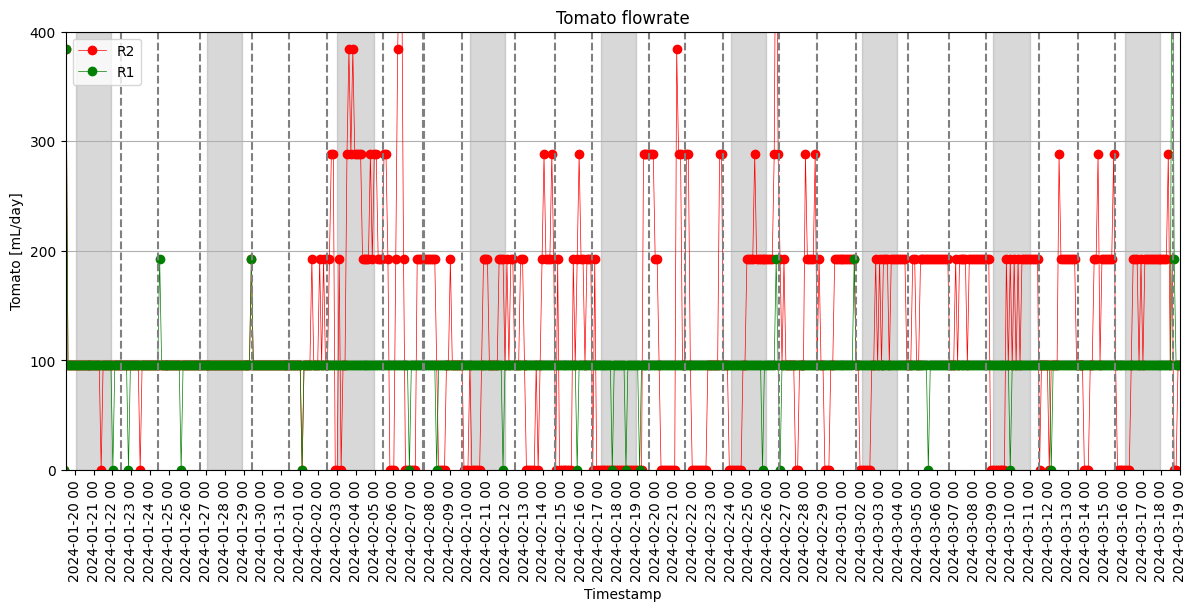

In [55]:
# TOMATO GROUPED EVERY 2.5 HOURS FOR COMBI
import matplotlib.dates as mdates
from matplotlib.dates import date2num
# Plot the overall time series
plt.figure(figsize=(12, 6))
plt.plot(groupby_tomato[1]['Timestamp'], groupby_tomato[1]['tomato']*96, color='r', label='R2',linewidth=0.5, marker = 'o')
plt.plot(groupby_tomato[0]['Timestamp'], groupby_tomato[0]['tomato']*96, color='g', label='R1',linewidth=0.5, marker = 'o')

for time_instant in specific_time_instants:
    plt.axvline(pd.to_datetime(time_instant), color='grey', linestyle='dashed')#, label=f'{time_instant}')

plt.xlabel('Timestamp')
plt.ylabel('Tomato [mL/day]')
title = 'Tomato flowrate'
plt.title(title)
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
ax = plt.gca()
#ax.set_xlim([xmin, xmax])
#ax.set_ylim([0, 5])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

# Set x-axis limits with timestamps (from 10:30 AM to 12:30 PM)
start_time = datetime(2024, 1, 19, 12, 0)
end_time = datetime(2024, 3, 19, 0, 0)

plt.xlim(mdates.date2num(start_time), mdates.date2num(end_time))
ax = plt.gca()
#ax.set_ylim([42, 42.4])
#ax.set_xlim([15000,15015])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d %H')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.HourLocator(interval=24))

# Specify the number of ticks on the y-axis
num_ticks = 5  # Adjust this value as needed

# Calculate tick positions based on the number of ticks
min_value = 0
max_value = 400
ax.set_ylim([min_value, max_value])
y_ticks = [min_value + i * ((max_value - min_value) / (num_ticks - 1)) for i in range(num_ticks)]

# Highlight weekends with grey color based on the timestamp column
weekend_mask = (groupby_tomato[1]['Timestamp'].dt.weekday >= 5)  # Saturday and Sunday
plt.fill_between(groupby_tomato[1]['Timestamp'], 0, max_value, where=weekend_mask, color='grey', alpha=0.3, label='Weekends')

# Set the ticks on the y-axis
plt.yticks(y_ticks)

plt.grid(axis='y')

# Specify the directory to save the figure
save_directory = 'C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Sperimentazione UIT/Software/'

# Save the plot to the specified directory with a desired filename
plt.savefig(save_directory + f'{title}_{current_date}.png')

plt.show()

In [17]:
# Computation of daily methane production
# Convert 'timestamp' to datetime if it's not already in datetime format
R2['Timestamp'] = pd.to_datetime(R2['Timestamp'])

# Group by day and calculate the sum for each group
CH4_tot_daily_sum_R2 = R2.groupby(R2['Timestamp'].dt.date)['ch4_rate_moving_average'].sum().reset_index()
CH4_tot_daily_sum_R2['ch4_rate_moving_average'] = CH4_tot_daily_sum_R2['ch4_rate_moving_average']/60 #L/day
CH4_tot_daily_sum_R2['COD_gas'] = CH4_tot_daily_sum_R2['ch4_rate_moving_average']*273/303/0.35

CH4_tot_daily_sum_R1 = R1.groupby(R1['Timestamp'].dt.date)['ch4_rate_moving_average'].sum().reset_index()
CH4_tot_daily_sum_R1['ch4_rate_moving_average'] = CH4_tot_daily_sum_R1['ch4_rate_moving_average']/60 #L/day
CH4_tot_daily_sum_R1['COD_gas'] = CH4_tot_daily_sum_R1['ch4_rate_moving_average']*273/303/0.35

Daily_methane = pd.concat([CH4_tot_daily_sum_R2, CH4_tot_daily_sum_R1], axis=1)

column_names = ['TimestampR2','CH4 R2 [L/day]','COD R2 [g/day]','TimestampR1','CH4 R1 [L/day]','COD R1 [g/day]']
Daily_methane.columns = column_names

# Print the resulting DataFrame
print(Daily_methane)

   TimestampR2  CH4 R2 [L/day]  COD R2 [g/day] TimestampR1  CH4 R1 [L/day]  \
0   2024-01-19        8.054752       20.735004  2024-01-19        6.194129   
1   2024-01-20       10.323026       26.574127  2024-01-20        9.623349   
2   2024-01-21        8.306524       21.383130  2024-01-21        7.308271   
3   2024-01-22        8.447268       21.745442  2024-01-22        7.121608   
4   2024-01-23        8.531965       21.963475  2024-01-23        7.575594   
..         ...             ...             ...         ...             ...   
77  2024-04-05        3.618050        9.313793  2024-04-05        2.860107   
78  2024-04-06        3.483093        8.966379  2024-04-06        2.782190   
79  2024-04-07        3.743450        9.636603  2024-04-07        2.693099   
80  2024-04-08        3.414069        8.788691  2024-04-08        1.616169   
81  2024-04-09        3.469624        8.931704  2024-04-09        2.270391   

    COD R1 [g/day]  
0        15.945284  
1        24.772977  


In [19]:
def cumulate_values_in_range(df, timestamp_col, value_col, start_time, end_time):
    # Ensure the timestamp column is of type datetime64[ns]
    df[timestamp_col] = pd.to_datetime(df[timestamp_col])

    # Filter the DataFrame based on the specified timestamp range
    filtered_df = df[(df[timestamp_col] >= start_time) & (df[timestamp_col] <= end_time)]

    # Cumulate values in the specified range
    cumulated_value = filtered_df[value_col].sum()

    return cumulated_value

df = Daily_methane

start_time = '2024-03-26 12:00'
end_time = '2024-04-10 12:00'
cumulated_value = cumulate_values_in_range(df, 'TimestampR2', 'CH4 R2 [L/day]', start_time, end_time)

print(f'Cumulated value for the range {start_time} to {end_time}: {cumulated_value}')

Cumulated value for the range 2024-03-26 12:00 to 2024-04-10 12:00: 70.20110833333334


In [351]:
df = groupby_tomato[0]

start_time = '2024-01-31 12:00'
end_time = '2024-02-23 12:00'
cumulated_value = cumulate_values_in_range(df, 'Timestamp', 'tomato', start_time, end_time)*10*80.5/1000

print(f'COD_tomato for the range {start_time} to {end_time}: {cumulated_value}')

COD_tomato for the range 2024-01-31 12:00 to 2024-02-23 12:00: 172.27


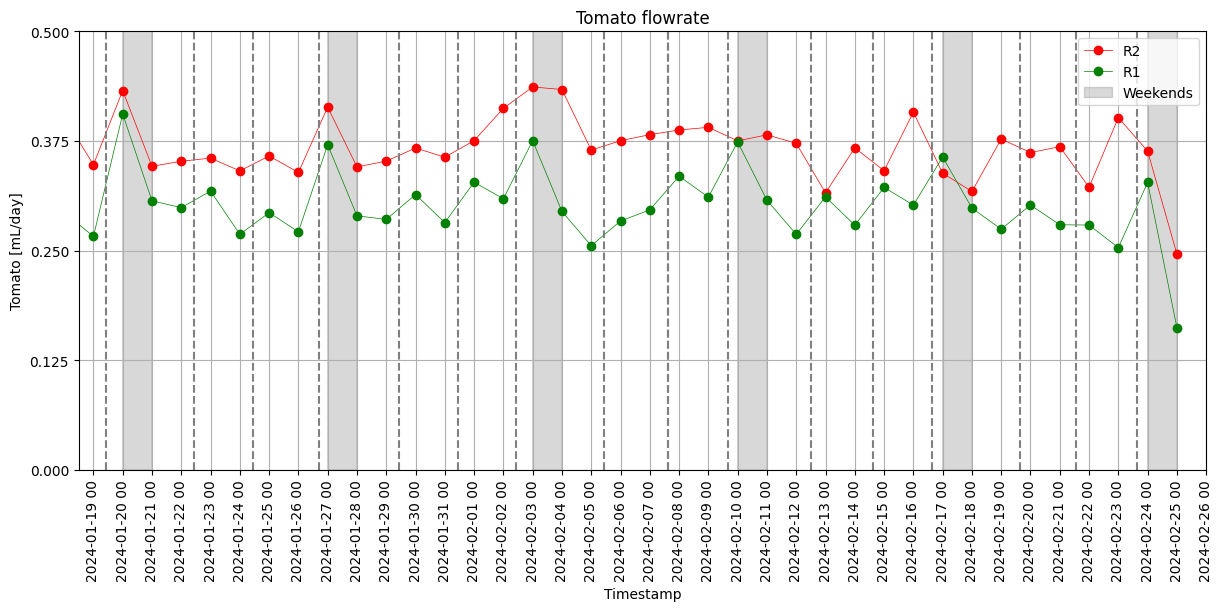

In [326]:
# COMPARISON DAILY AVERAGE PRODUCTION R1 VS R2 VS SETPOINT
# Plot the overall time series
plt.figure(figsize=(12, 6))
plt.plot(Daily_methane['TimestampR2'],Daily_methane['CH4 R2 [L/day]']/24, color='r', label='R2',linewidth=0.5, marker = 'o')
plt.plot(Daily_methane['TimestampR1'],Daily_methane['CH4 R1 [L/day]']/24, color='g', label='R1',linewidth=0.5, marker = 'o')
Daily_methane['TimestampR2'] = pd.to_datetime(Daily_methane['TimestampR2'])

# Highlight weekends with grey color based on the timestamp column
weekend_mask = (Daily_methane['TimestampR2'].dt.weekday >= 5)  # Saturday and Sunday
plt.fill_between(Daily_methane['TimestampR2'], 0, Daily_methane['CH4 R2 [L/day]']/2, where=weekend_mask, color='grey', alpha=0.3, label='Weekends')

# Add vertical dotted lines at specific time instants
specific_time_instants = ['2023-11-10 12:30' ,'2023-11-13 12:30', '2023-11-15 12:30', 
                          '2023-11-17 12:30', '2023-11-20 12:30', '2023-11-22 12:30', 
                          '2023-11-24 12:30', '2023-11-27 12:30', '2023-11-29 12:30',
                          '2023-12-1 14:30', '2023-12-4 16:00', '2023-12-6 12:00',
                         '2023-12-8 13:30','2023-12-11 13:30','2023-12-13 13:30',
                          '2023-12-15 13:30','2023-12-18 13:30','2023-12-20 13:30','2023-12-22 15:30',
                          '2024-1-8 10:30','2024-1-10 10:30','2024-1-12 10:30','2024-1-15 10:30',
                         '2024-1-17 10:30','2024-1-19 10:30','2024-1-22 10:30','2024-1-24 10:30',
                          '2024-1-26 16:30','2024-1-29 10:30','2024-1-31 10:30','2024-2-2 10:30',
                          '2024-2-5 10:30','2024-2-7 14:30','2024-2-7 15:00','2024-2-9 16:15',
                          '2024-2-12 11:45','2024-2-14 15:00','2024-2-16 15:00','2024-2-19 15:00',
                          '2024-2-21 13:15','2024-2-23 15:00'
                         ]
for time_instant in specific_time_instants:
    plt.axvline(pd.to_datetime(time_instant), color='grey', linestyle='dashed')#, label=f'{time_instant}')

plt.xlabel('Timestamp')
plt.ylabel('Tomato [mL/day]')
title = 'Tomato flowrate'
plt.title(title)
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
ax = plt.gca()
#ax.set_xlim([xmin, xmax])
#ax.set_ylim([0, 5])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

# Set x-axis limits with timestamps (from 10:30 AM to 12:30 PM)
start_time = datetime(2024, 1, 18, 12, 0)
end_time = datetime(2024, 2, 26, 0, 0)

plt.xlim(mdates.date2num(start_time), mdates.date2num(end_time))
ax = plt.gca()
#ax.set_ylim([42, 42.4])
#ax.set_xlim([15000,15015])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d %H')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.HourLocator(interval=24))

# Specify the number of ticks on the y-axis
num_ticks = 5  # Adjust this value as needed

# Calculate tick positions based on the number of ticks
min_value = 0
max_value = 0.5
ax.set_ylim([min_value, max_value])
y_ticks = [min_value + i * ((max_value - min_value) / (num_ticks - 1)) for i in range(num_ticks)]

# Set the ticks on the y-axis
plt.yticks(y_ticks)

plt.grid()

# Specify the directory to save the figure
save_directory = 'C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Sperimentazione UIT/Software/'

# Save the plot to the specified directory with a desired filename
#plt.savefig(save_directory + f'{title}_{current_date}.png')

plt.show()

In [64]:
def read_excel_file(file_path,exclude_sheet):
    # Read the Excel file and return a dictionary of DataFrames for each sheet
    xls = pd.ExcelFile(file_path)
    sheets_to_read = [sheet for sheet in xls.sheet_names if sheet not in exclude_sheet]
    sheet_dict = {sheet_name: pd.read_excel(xls, sheet_name) for sheet_name in sheets_to_read}
    return sheet_dict

# LOAD OFFLINE DATA
offline_data_path = 'C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Sperimentazione UIT/Data_UIT_22.04.2024.xlsx'
offline_UIT_data = read_excel_file(offline_data_path,['SteadyState'])
# Use a dictionary comprehension to filter the original dictionary
offline_UIT_data = {key: offline_UIT_data[key] for key in ['R1 measurements','R2 measurements','R1 feed','R2 feed'] if key in offline_UIT_data}

#Eliminate np.nan values
keys_to_exclude = []
subset_keys = [key for key in offline_UIT_data.keys() if key not in keys_to_exclude]
for key in subset_keys:
    df_filtered = offline_UIT_data[key].dropna(subset=['pHs'])
    #df_numeric = df_filtered.apply(pd.to_numeric, errors='coerce').iloc[1:]
    df_filtered['Timestamp'] = pd.to_datetime(df_filtered['Timestamp'],format='%d-%m-%Y %H:%M')
    # Round to the nearest hour
    df_filtered['Timestamp'] = df_filtered['Timestamp'].dt.round('H')

    # Identify the index of the timestamp column
    timestamp_column_index = df_filtered.columns.get_loc('Timestamp')

    # Convert columns after the timestamp column to numeric
    for col in df_filtered.columns[timestamp_column_index + 1:]:
        df_filtered[col] = pd.to_numeric(df_filtered[col], errors='coerce')
    #df_numeric = df_filtered.apply(pd.to_numeric, errors='coerce').iloc[1:]
    df_numeric = df_filtered.iloc[1:]
    offline_UIT_data[key] = df_filtered

C:\ModelonImpact-1.8.1\oct-dist\myEnv\lib\site-packages\ipykernel_launcher.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\ModelonImpact-1.8.1\oct-dist\myEnv\lib\site-packages\ipykernel_launcher.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\ModelonImpact-1.8.1\oct-dist\myEnv\lib\site-packages\ipykernel_launcher.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docume

In [163]:
# Computation of CODin
# Convert 'timestamp' to datetime if it's not already in datetime format
df1 = offline_UIT_data['R1 feed']
df2 = offline_UIT_data['R2 feed']
df1['Timestamp'] = pd.to_datetime(df1['Timestamp'])
df2['Timestamp'] = pd.to_datetime(df2['Timestamp'])

# Group by day and calculate the sum for each group
Feed_R1 = pd.DataFrame()
Feed_R2 = pd.DataFrame()
columns_to_process = ['Slurry','Maize','Tomato']
for column in columns_to_process:
    Feed_tot_daily_sum_R2 = df2.groupby(df2['Timestamp'].dt.date)[column].sum().reset_index()
    Feed_tot_daily_sum_R1 = df1.groupby(df1['Timestamp'].dt.date)[column].sum().reset_index()
    
    Feed_R1[column] = Feed_tot_daily_sum_R1[column]
    Feed_R2[column] = Feed_tot_daily_sum_R2[column]

Feed = pd.concat([Feed_tot_daily_sum_R2['Timestamp'],Feed_R2, Feed_R1], axis=1)

column_names = ['Timestamp',
                'Slurry R2 [L/day]',
                'Maize R2 [L/day]',
                'Tomato R2 [L/day]',
                'Slurry R1 [L/day]',
                'Maize R1 [L/day]',
                'Tomato R1 [L/day]',
               ]
Feed.columns = column_names

# Print the resulting DataFrame
print(Feed)

     Timestamp  Slurry R2 [L/day]  Maize R2 [L/day]  Tomato R2 [L/day]  \
0   2023-10-23         486.000000        122.000000               0.00   
1   2023-10-25         486.000000        122.000000               0.00   
2   2023-10-27         730.000000        183.000000               0.00   
3   2023-11-03         730.000000        183.000000               0.00   
4   2023-11-06         486.000000        122.000000             273.86   
5   2023-11-08         486.000000        122.000000             192.69   
6   2023-11-10         730.000000        183.000000               0.00   
7   2023-11-13         486.000000        122.000000             248.29   
8   2023-11-15         486.000000        122.000000             174.89   
9   2023-11-17         730.000000        183.000000              75.19   
10  2023-11-20         486.000000        122.000000              83.73   
11  2023-11-22         486.000000        122.000000             473.39   
12  2023-11-24         730.000000     

In [164]:
def cumulate_values_in_range(df, timestamp_col, value_col, start_time, end_time):
    # Ensure the timestamp column is of type datetime64[ns]
    df[timestamp_col] = pd.to_datetime(df[timestamp_col])

    # Filter the DataFrame based on the specified timestamp range
    filtered_df = df[(df[timestamp_col] >= start_time) & (df[timestamp_col] <= end_time)]

    # Cumulate values in the specified range
    cumulated_value = filtered_df[value_col].sum()

    return cumulated_value

df = Feed

start_time = '2024-02-5'
end_time = '2024-02-11'
cumulated_value = cumulate_values_in_range(df, 'Timestamp', 'Slurry R2 [L/day]', start_time, end_time)

print(f'Cumulated value for the range {start_time} to {end_time}: {cumulated_value}')

Cumulated value for the range 2024-02-5 to 2024-02-11: 1555.235294117647


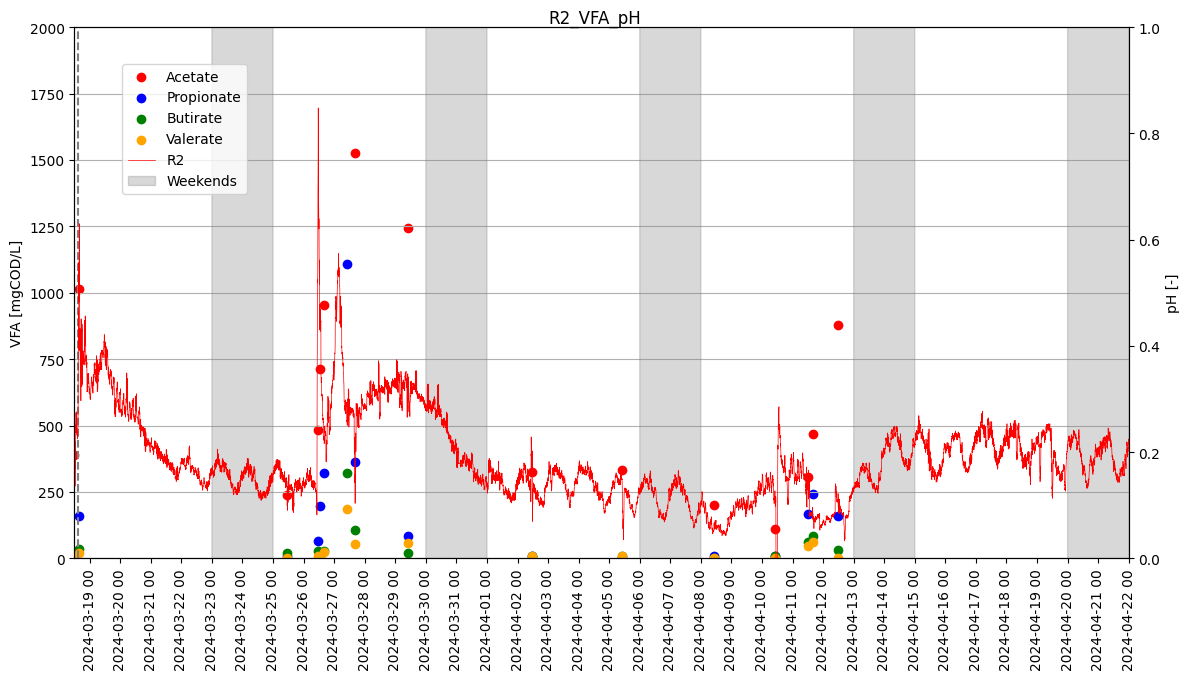

In [73]:
# Check correlation between ratio and deltaQch4 
# based on timestamp-based series
from matplotlib.dates import DateFormatter
reactor = '1'
# Create a figure and axis
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.scatter(offline_UIT_data[f'R{reactor} measurements']['Timestamp'],offline_UIT_data[f'R{reactor} measurements']['Acetate'], marker='o', linestyle='-', color='r',label = 'Acetate')
ax1.scatter(offline_UIT_data[f'R{reactor} measurements']['Timestamp'],offline_UIT_data[f'R{reactor} measurements']['Propionate'], marker='o', linestyle='-', color='b',label = 'Propionate')
ax1.scatter(offline_UIT_data[f'R{reactor} measurements']['Timestamp'],offline_UIT_data[f'R{reactor} measurements']['Butirate'], marker='o', linestyle='-', color='g',label = 'Butirate')
ax1.scatter(offline_UIT_data[f'R{reactor} measurements']['Timestamp'],offline_UIT_data[f'R{reactor} measurements']['Valerate'], marker='o', linestyle='-', color='orange',label = 'Valerate')
#ax1.set_xlabel('X-axis')
ax1.set_ylabel('VFA [mgCOD/L]')
ax1.tick_params(axis='y')
ymax = 2000
ax1.set_ylim([0,ymax])

# Create a secondary y-axis (ax2) sharing the same x-axis
ax2 = ax1.twinx()
#ax2.plot(R2['Timestamp'], 1/R2['gas_ratio'], color='red', label='R2',linewidth=0.5)
ax2.plot(R1['Timestamp'], R1['ch4_rate_moving_average'], color='red', label='R2',linewidth=0.5)
#ax2.plot(R2['Timestamp'], R2['2Q1 [pH]_out'], color='black', label='pH',linewidth=0.5)
ax2.set_ylabel('pH [-]')
ax2.set_ylim([0,1])

for time_instant in specific_time_instants:
    ax1.axvline(pd.to_datetime(time_instant), color='grey', linestyle='dashed')#, label=f'{time_instant}')
    
# Highlight weekends with grey color based on the timestamp column
weekend_mask = (R2['Timestamp'].dt.weekday >= 5)  # Saturday and Sunday
plt.fill_between(R2['Timestamp'], 0, ymax, where=weekend_mask, color='grey', alpha=0.3, label='Weekends')

plt.xticks(rotation=90)
plt.tight_layout()
# Set the locator for the x-axis to show every day
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=24))
# Set x-axis limits with timestamps (from 10:30 AM to 12:30 PM)
start_time = datetime(2024, 3, 18, 12, 0)
end_time = datetime(2024, 4, 22, 0, 0)

plt.xlim(mdates.date2num(start_time), mdates.date2num(end_time))
#ax.set_ylim([42, 42.4])
#ax.set_xlim([15000,15015])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d %H')
ax1.xaxis.set_major_formatter(date_format)

# Customize x-axis options
ax1.xaxis.set_major_formatter(DateFormatter('%Y-%m-%d %H'))  # Format dates
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=24))  # Set the number of bins
ax1.tick_params(axis='x', rotation=90)  # Rotate x-axis labels

# Show the legend
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
# Add a title to the entire figure
plt.suptitle('R2_VFA_pH')
# Adjust the layout to leave more space for the title
plt.subplots_adjust(top=0.95)

# Specify the directory to save the figure
save_directory = 'C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Sperimentazione UIT/Software/'

# Save the plot to the specified directory with a desired filename
#plt.savefig(save_directory + f'{title}_{current_date}.png')

ax1.grid(axis='y')
plt.show()

In [14]:
# For CDC 2024 abstract:
# I HAVE TO FILTER IT BEFORE PLOTTING TO EXCLUDE NON-CALIB REGIONS
start_time = '2024-1-19 12:00'
end_time = '2024-2-5 12:00'
# Qch4 R2
groupby_Qch4[1]['Timestamp'] = pd.to_datetime(groupby_Qch4[1]['Timestamp'])
filtered_df = groupby_Qch4[1][(groupby_Qch4[1]['Timestamp'] >= start_time) & (groupby_Qch4[1]['Timestamp'] <= end_time)]
filtered_df.reset_index(drop=True, inplace=True)
# Qh4 R1
groupby_Qch4[0]['Timestamp'] = pd.to_datetime(groupby_Qch4[0]['Timestamp'])
filtered_df1 = groupby_Qch4[0][(groupby_Qch4[0]['Timestamp'] >= start_time) & (groupby_Qch4[0]['Timestamp'] <= end_time)]
filtered_df1.reset_index(drop=True, inplace=True)


# Qch4 setpoint
start_time = '2024-1-22 12:00'
end_time = '2024-2-8 12:00'
setpoint_data['Timestamp'] = pd.to_datetime(setpoint_data['Timestamp'])
filtered_set = setpoint_data[(setpoint_data['Timestamp'] >= start_time) & (setpoint_data['Timestamp'] <= end_time)]
filtered_set.reset_index(drop=True, inplace=True)

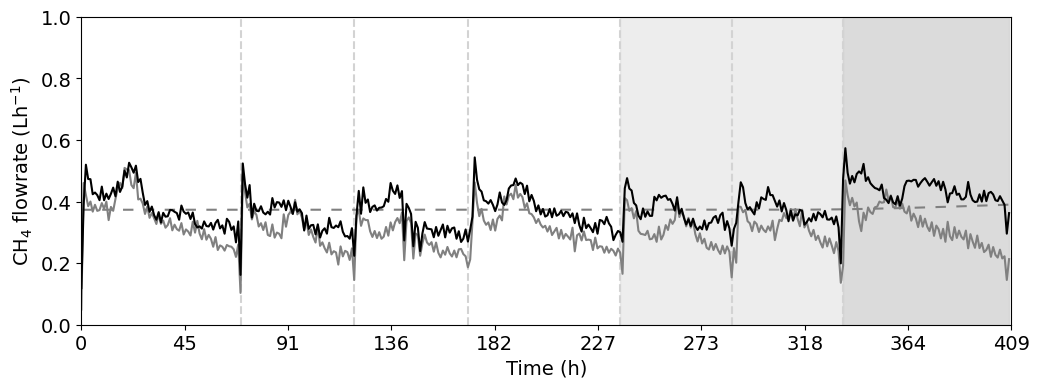

In [23]:
from matplotlib.ticker import FuncFormatter
# For CDC 2024 abstract:
# I HAVE TO FILTER IT BEFORE PLOTTING TO EXCLUDE NON-CALIB REGIONS
# Show also VFA curve data or not?
# METHANE
plt.figure(figsize=(12, 4))
    
#pl.legend(fontsize=12)
ax = pl.gca()
ax.set_ylim([0, 1])
plt.ylabel(r'CH$_4$ flowrate (Lh$^{-1}$)',fontsize=14)
plt.xlabel('Time (h)',fontsize=14)
#plt.title('CH4 flowrate')

# Add vertical dotted lines at specific time instants
specific_time_instants = [70,120,170,237,286,335
                         ]
for time_instant in specific_time_instants:
    ax.axvline(time_instant, color='lightgrey', linestyle='dashed')#, label=f'{time_instant}')

plt.plot(filtered_set['Setpoint1']+0.057, label=r'$Q_{ch4}^*$',color='grey',linestyle ='--',dashes=(5, 5))  # Replace 'variable_name' with your actual variable name
pl.plot(filtered_df1['ch4_rate'], label = r'$Q_{ch4,R1}$', color='grey')
pl.plot(filtered_df['ch4_rate'], label = r'$Q_{ch4,R2}$', color='black')

#Mask 
control = filtered_df.loc[(filtered_df.index >= 237) & (filtered_df.index <= 335)]
plt.fill_between(control.index, 0, 1, color='lightgray', label='Masked Region',alpha=0.4)
ramp = filtered_df.loc[(filtered_df.index >= 335) & (filtered_df.index <= 409)]
plt.fill_between(ramp.index, 0, 1, color='lightgray', label='Masked Region',alpha=0.8)

# Calculate tick positions based on the number of ticks
num_ticks = 10
min_value = 0
max_value = len(filtered_df['ch4_rate'])
ax.set_xlim([min_value, max_value])
x_ticks = [min_value + i * ((max_value - min_value) / (num_ticks - 1)) for i in range(num_ticks)]

# Set the ticks on the y-axis
plt.xticks(x_ticks,fontsize=14)
plt.yticks(fontsize=14)

# Round x-axis tick values to 2 decimal places
decimal_places = 0
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.{decimal_places}f}'))

#pl.grid()

# Specify the directory to save the figure
save_directory = 'C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Conferences and papers/CDC24/'

# Save the plot to the specified directory with a desired filename
plt.savefig(save_directory + 'Data_Qch4_control.pdf',format='pdf', dpi=300, bbox_inches='tight')

pl.show()

In [ ]:
# ANNEX -----------------------------------------------------------------------------------------------------------------------

In [ ]:
#To check outlier values and position
#outliers = R2['2F1.1 [L/h]'][outlier_indices]
#plt.figure(figsize=(12, 6))
#plt.scatter(outlier_indices,outliers)
#ax = plt.gca()
#ax.set_xlim([7500, 8000])
#ax.set_ylim([0, 6])

In [ ]:
#HOW TO AVERAGE DATA WHEN THERE ARE STEPS? es T

In [ ]:
#Alternative way to compute the z-score 
#(with average computed on the sliding window, not on the overall time series)
def zscore(s, window, thresh=3, return_all=False):
    roll = s.rolling(window=window, min_periods=1, center=True)
    avg = roll.mean()
    std = roll.std(ddof=0)
    z = s.sub(avg).div(std)   
    m = z.between(-thresh, thresh)
    
    if return_all:
        return z, avg, std, m
    return s.where(m, avg)

combined_dataframe['2F1.1 [L/h]_out'] = zscore(combined_dataframe['2F1.1 [L/h]'], window=50)

z, avg, std, m = zscore(combined_dataframe['2F1.1 [L/h]'], window = 50, return_all=True)

ax = plt.subplot()

df['2F1.1 [L/h]'].plot(label='data')
avg.plot(label='mean')
df.loc[~m, '2F1.1 [L/h]'].plot(label='outliers', marker='o', ls='')
avg[~m].plot(label='replacement', marker='o', ls='')
plt.legend()

In [ ]:
# Resample the data in 15-minute intervals and calculate the sum of a column
resampled_data = data['2T1 [°C]'].resample('15T').sum()/15

In [ ]:
timestamp =pd.to_datetime(timestamp)